In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
test = pd.read_csv(r'../test.csv')
train = pd.read_csv(r'../train.csv')

In [3]:
df = train.copy()

In [4]:
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [5]:
test.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [7]:
df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [5]:
cat_cols = [i for i in df.columns if df[i].dtype=='object']

In [6]:
for i in cat_cols:
    print(df[i].value_counts())
    print("-"*30)

gender
other     211097
male      210593
female    208310
Name: count, dtype: int64
------------------------------
course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64
------------------------------
internet_access
yes    579423
no      50577
Name: count, dtype: int64
------------------------------
sleep_quality
poor       213675
good       213089
average    203236
Name: count, dtype: int64
------------------------------
study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64
------------------------------
facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64
------------------------------
exam_difficulty
moderate    353982
easy        176540
hard         99478
Name: count, dtype: int64
------------------------------


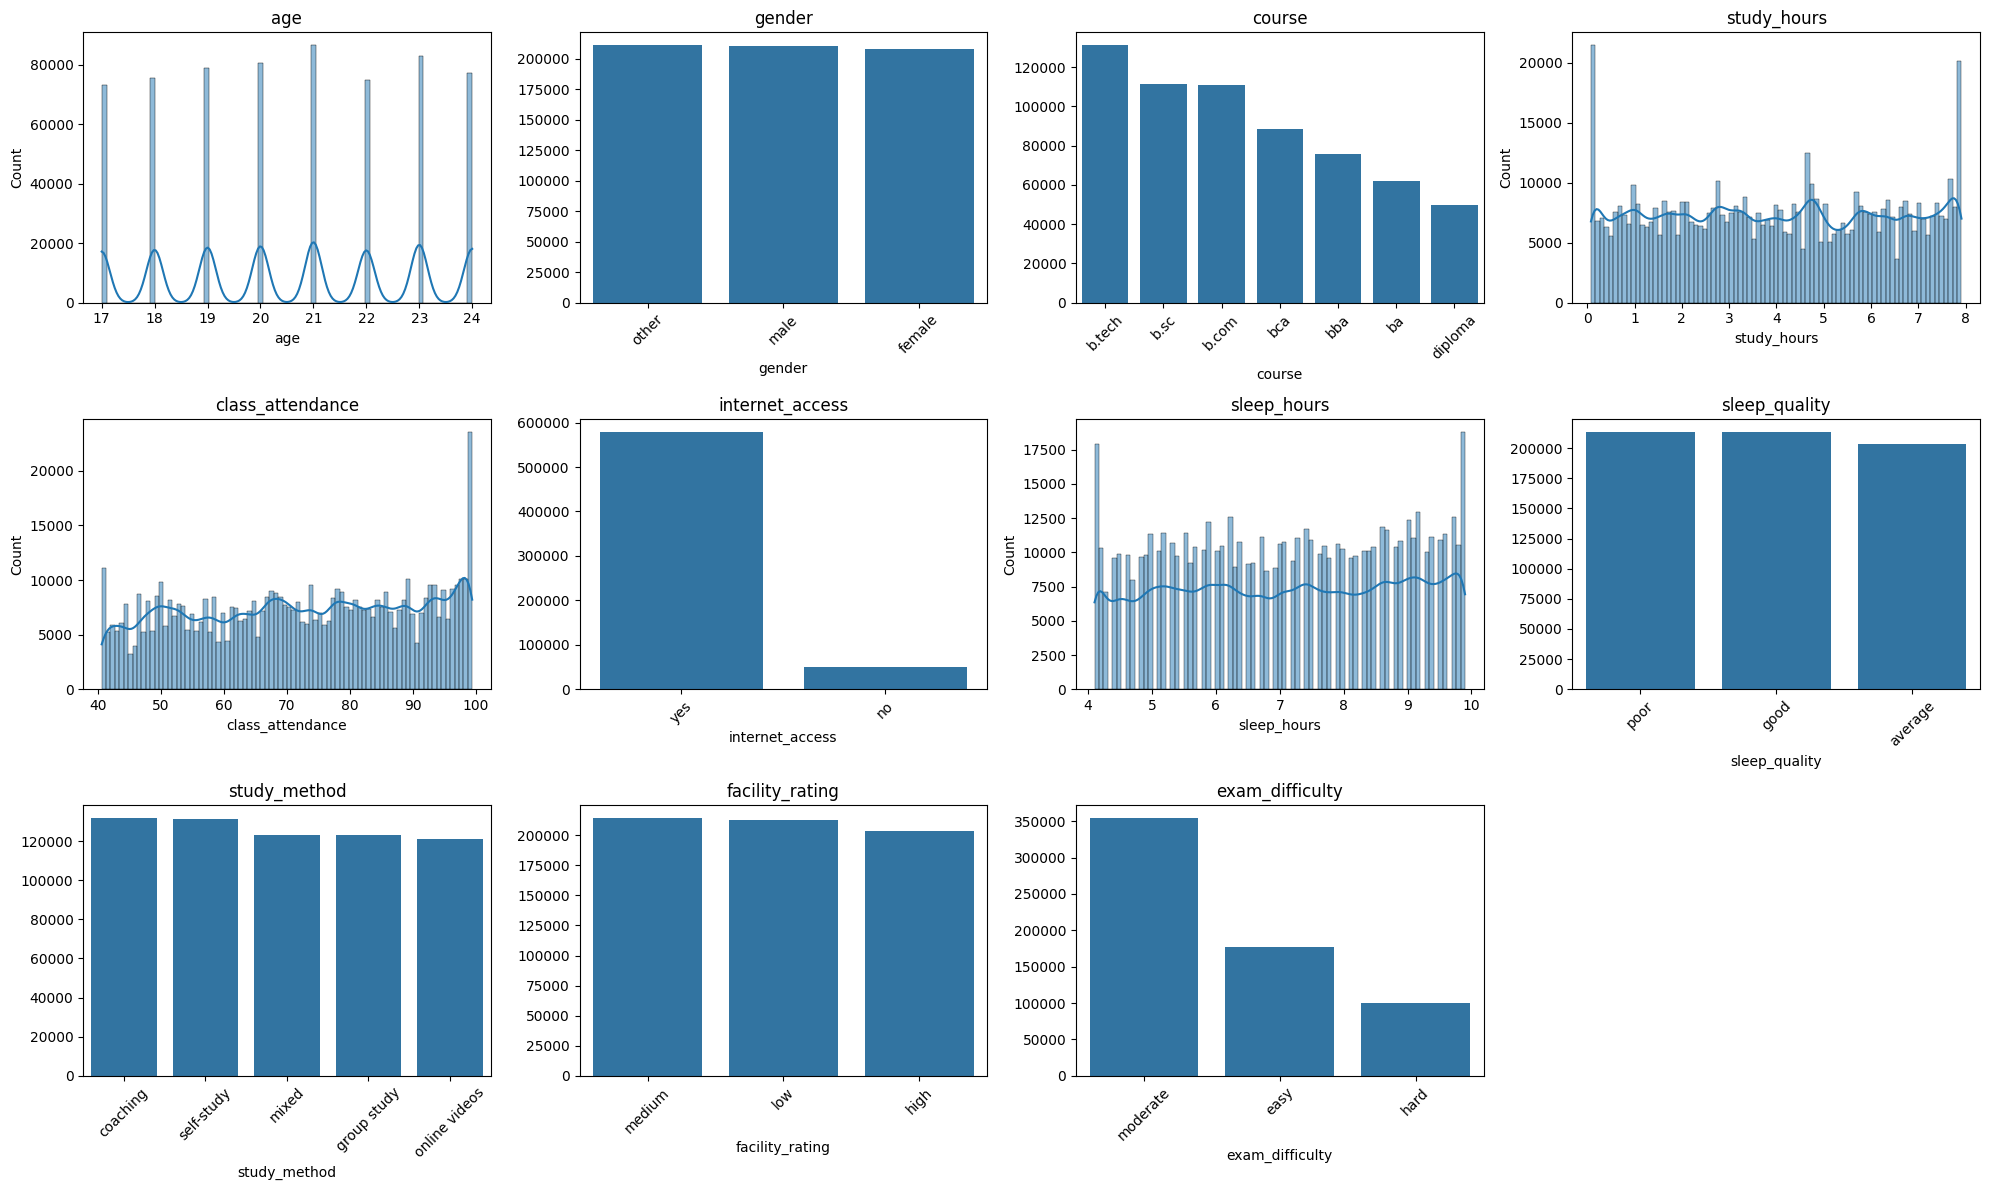

In [20]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_distributions_single_image(df, max_categories=15):
    cols = df.columns
    n_cols = 4
    n_rows = math.ceil(len(cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]

        if pd.api.types.is_numeric_dtype(df[col]):
            sns.histplot(df[col].dropna(), kde=True, ax=ax)
            ax.set_title(col)
        else:
            vc = df[col].value_counts().head(max_categories)
            sns.barplot(x=vc.index.astype(str), y=vc.values, ax=ax)
            ax.set_title(col)
            ax.tick_params(axis="x", rotation=45)

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_all_distributions_single_image(df.drop(columns=['id', 'exam_score']))


In [ ]:
df.colum

Index(['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

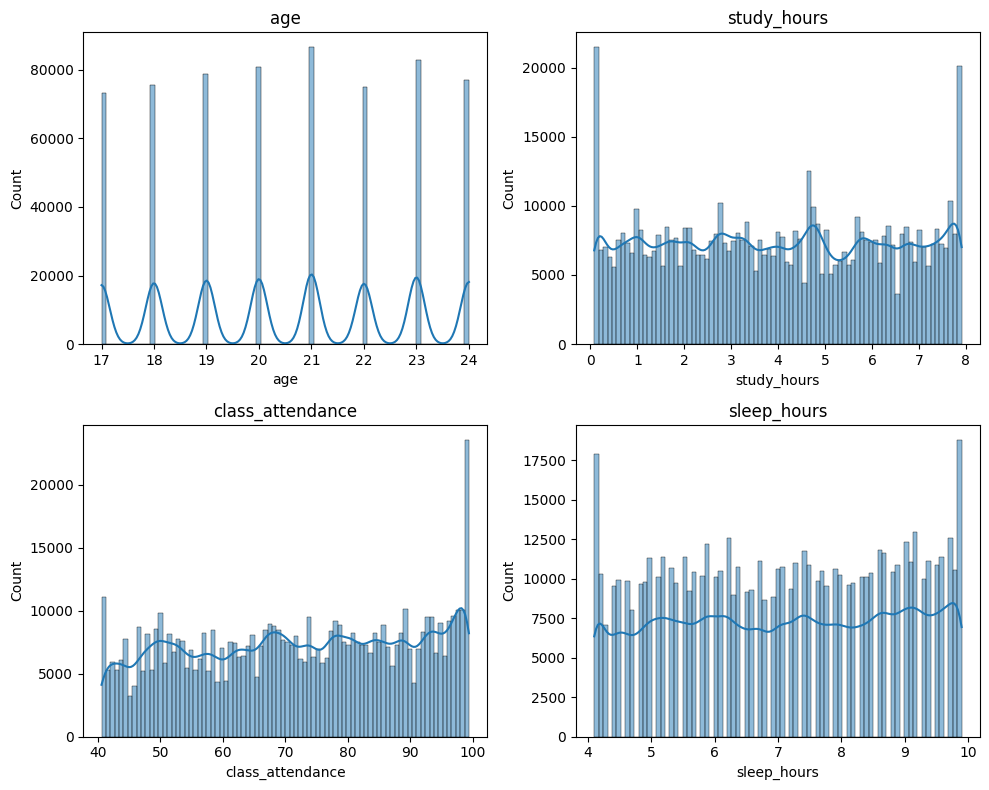

In [21]:
import math
def plot_numeric_distributions_single_image(df):
    numeric_cols = df.select_dtypes(include="number").columns

    n_cols = 2
    n_rows = math.ceil(len(numeric_cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
plot_numeric_distributions_single_image(df.drop(columns=['id', 'exam_score']))

<Axes: ylabel='Count'>

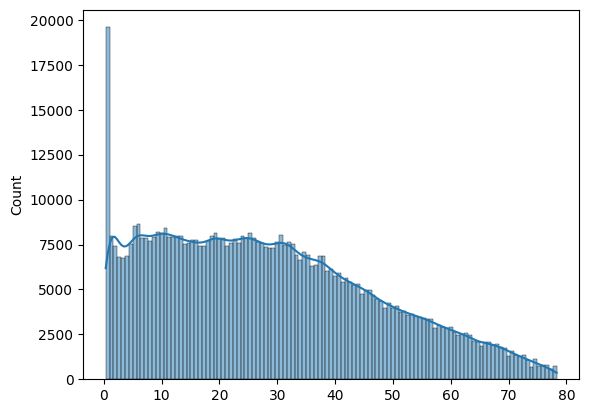

In [13]:
sns.histplot(df.study_hours * df.sleep_hours, kde=True)

<Axes: ylabel='Count'>

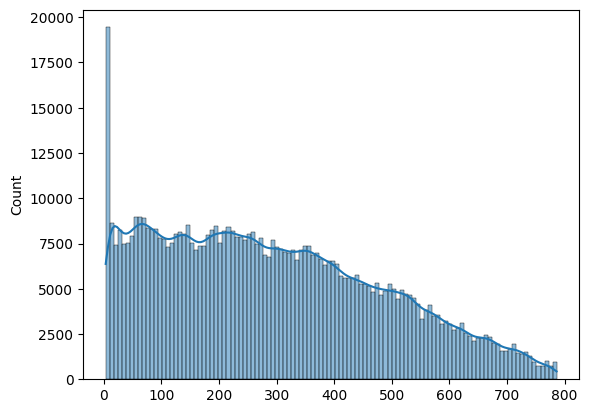

In [14]:
sns.histplot(df.study_hours * df.class_attendance, kde=True)

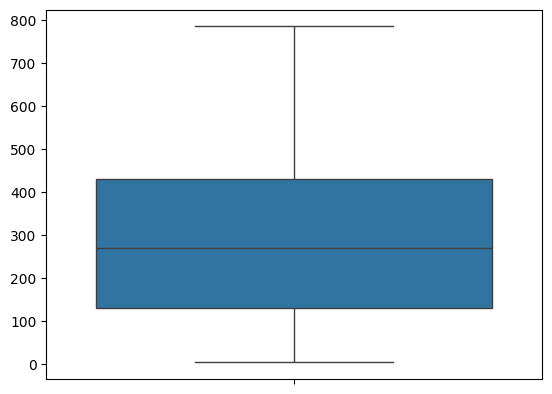

In [18]:
sns.boxplot(df.study_hours * df.class_attendance)
plt.show()

<Axes: >

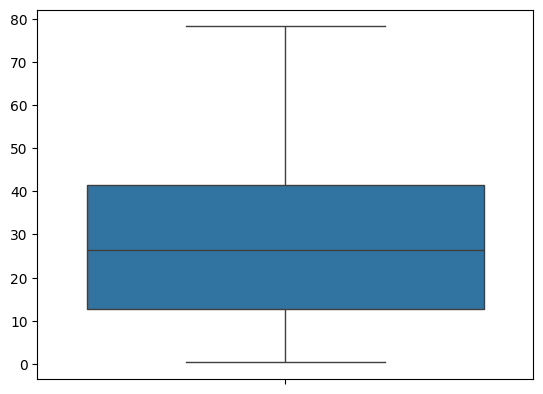

In [20]:
sns.boxplot(df.study_hours * df.sleep_hours)


<Axes: >

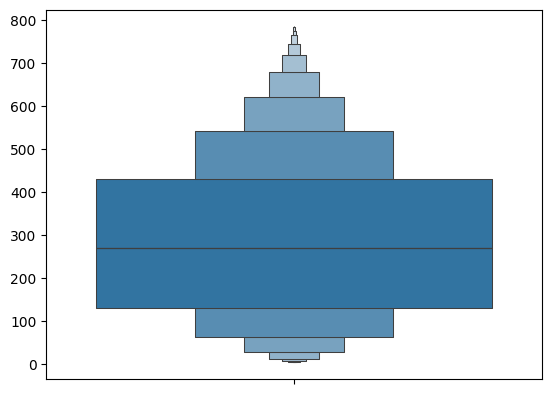

In [21]:
sns.boxenplot(df.study_hours * df.class_attendance)


<Axes: >

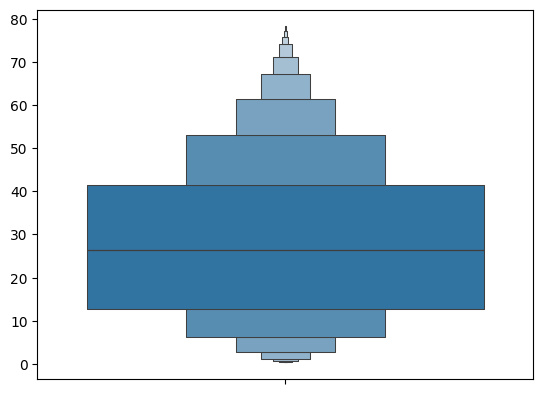

In [22]:
sns.boxenplot(df.study_hours * df.sleep_hours)


<Axes: >

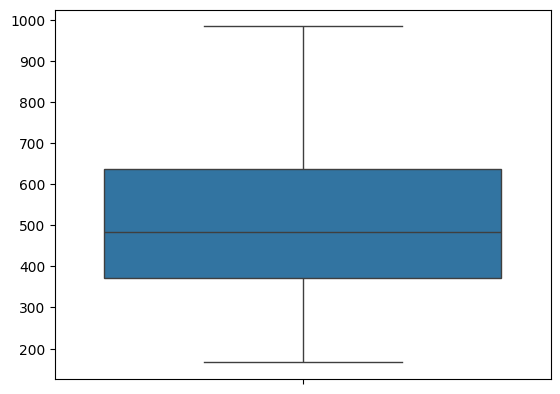

In [23]:
sns.boxplot(df.sleep_hours * df.class_attendance)


In [86]:
sub = test.copy()
pd.DataFrame(
    {
        "id": sub["id"],
        "exam_score": lgb_model.predict(
            preprocessing(sub.drop(columns="id")), 
            num_iteration=lgb_model.best_iteration
        )
    }
).to_csv(r"../submissions/submission01.csv", index=False)

with ordinal baseline
```
MAE: 6.990338928244827
RMSE: 8.765322626170775
R2: 0.783968802989175
```

without ordinal baseline
```
MAE: 6.992066565388619
RMSE: 8.76710253512816
R2: 0.783881058380237
```

with internet study_method interaction and better params
```
MAE: 6.97643809562767
RMSE: 8.75253506060119
R2: 0.7845986709644195
```

In [22]:
df.groupby("sleep_quality")["exam_score"].mean()


sleep_quality
average    62.662000
good       67.884885
poor       56.995470
Name: exam_score, dtype: float64

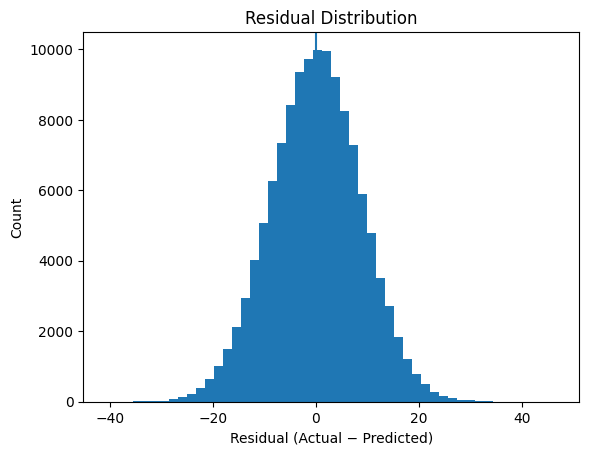

In [67]:
residuals = y_test.values - y_pred

res_df = X_test.copy()
res_df["actual"] = y_test.values
res_df["predicted"] = y_pred
res_df["residual"] = residuals
res_df["abs_residual"] = np.abs(residuals)

plt.figure()
plt.hist(residuals, bins=50)
plt.axvline(0)
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Count")
plt.show()


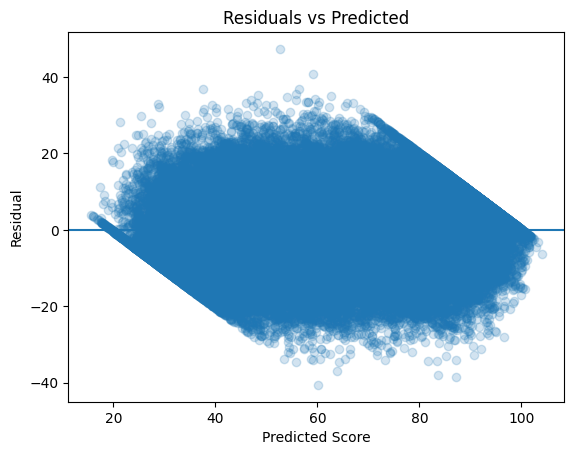

In [28]:
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.2)
plt.axhline(0)
plt.xlabel("Predicted Score")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()


<Figure size 640x480 with 0 Axes>

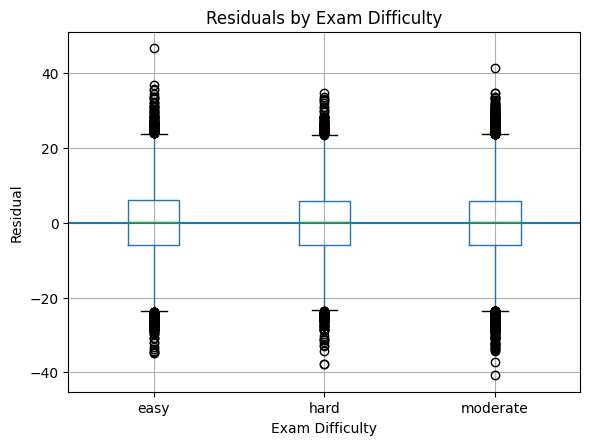

In [68]:
difficulty_map = {0: "easy", 1: "moderate", 2: "hard"}
res_df["exam_difficulty_label"] = res_df["exam_difficulty"].map(difficulty_map)

plt.figure()
res_df.boxplot(column="residual", by="exam_difficulty_label")
plt.axhline(0)
plt.title("Residuals by Exam Difficulty")
plt.suptitle("")
plt.xlabel("Exam Difficulty")
plt.ylabel("Residual")
plt.show()


<Figure size 640x480 with 0 Axes>

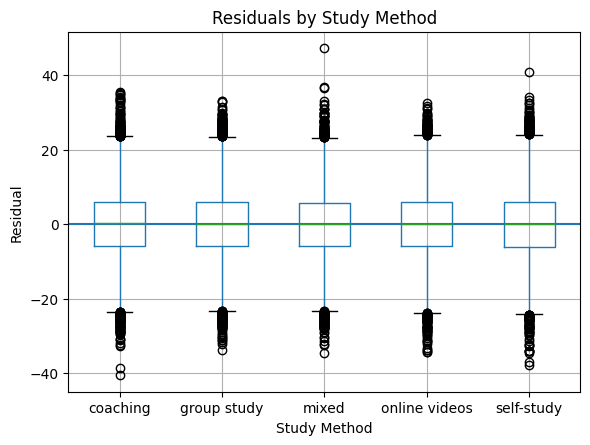

In [53]:
plt.figure()
res_df.boxplot(column="residual", by="study_method")
plt.axhline(0)
plt.title("Residuals by Study Method")
plt.suptitle("")
plt.xlabel("Study Method")
plt.ylabel("Residual")
plt.show()


<Figure size 640x480 with 0 Axes>

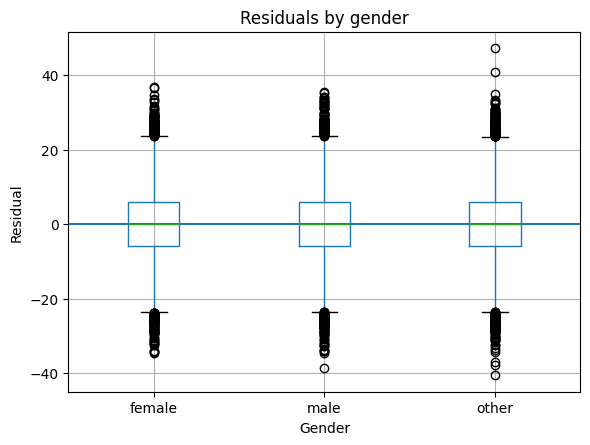

In [54]:
plt.figure()
res_df.boxplot(column="residual", by="gender")
plt.axhline(0)
plt.title("Residuals by gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Residual")
plt.show()


<Figure size 640x480 with 0 Axes>

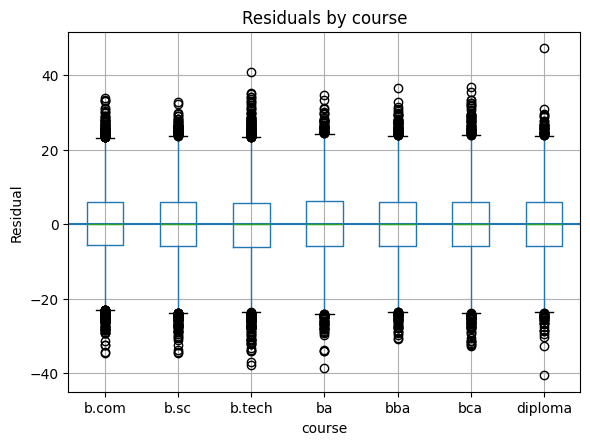

In [55]:
plt.figure()
res_df.boxplot(column="residual", by="course")
plt.axhline(0)
plt.title("Residuals by course")
plt.suptitle("")
plt.xlabel("course")
plt.ylabel("Residual")
plt.show()

In [72]:
res_df["sleep_hours_ceil"] = res_df.sleep_hours.apply(math.ceil)

<Figure size 1800x1500 with 0 Axes>

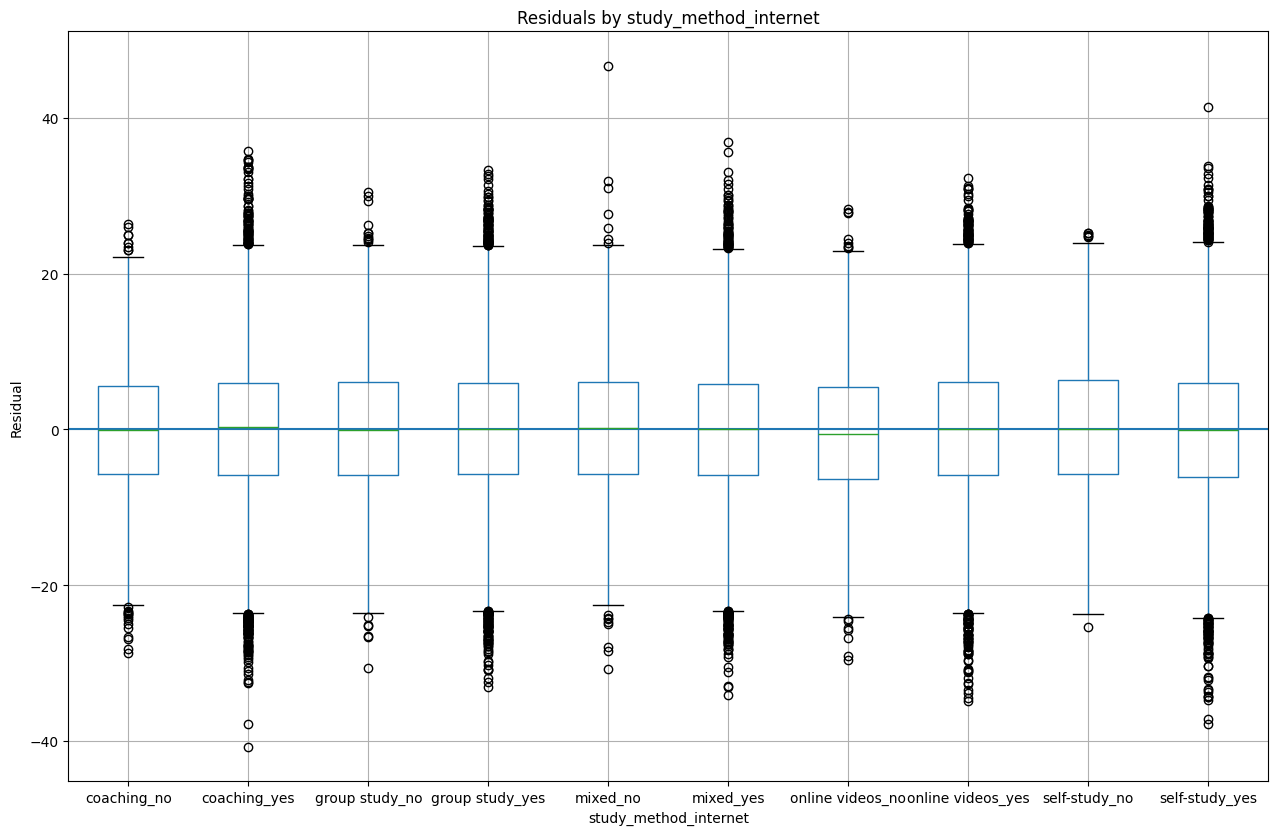

In [81]:
plt.figure(figsize=(18,15))
res_df.boxplot(column="residual", by="study_method_internet", figsize=(15,10))
plt.axhline(0)
plt.title("Residuals by study_method_internet")
plt.suptitle("")
plt.xlabel("study_method_internet")
plt.ylabel("Residual")
plt.show()

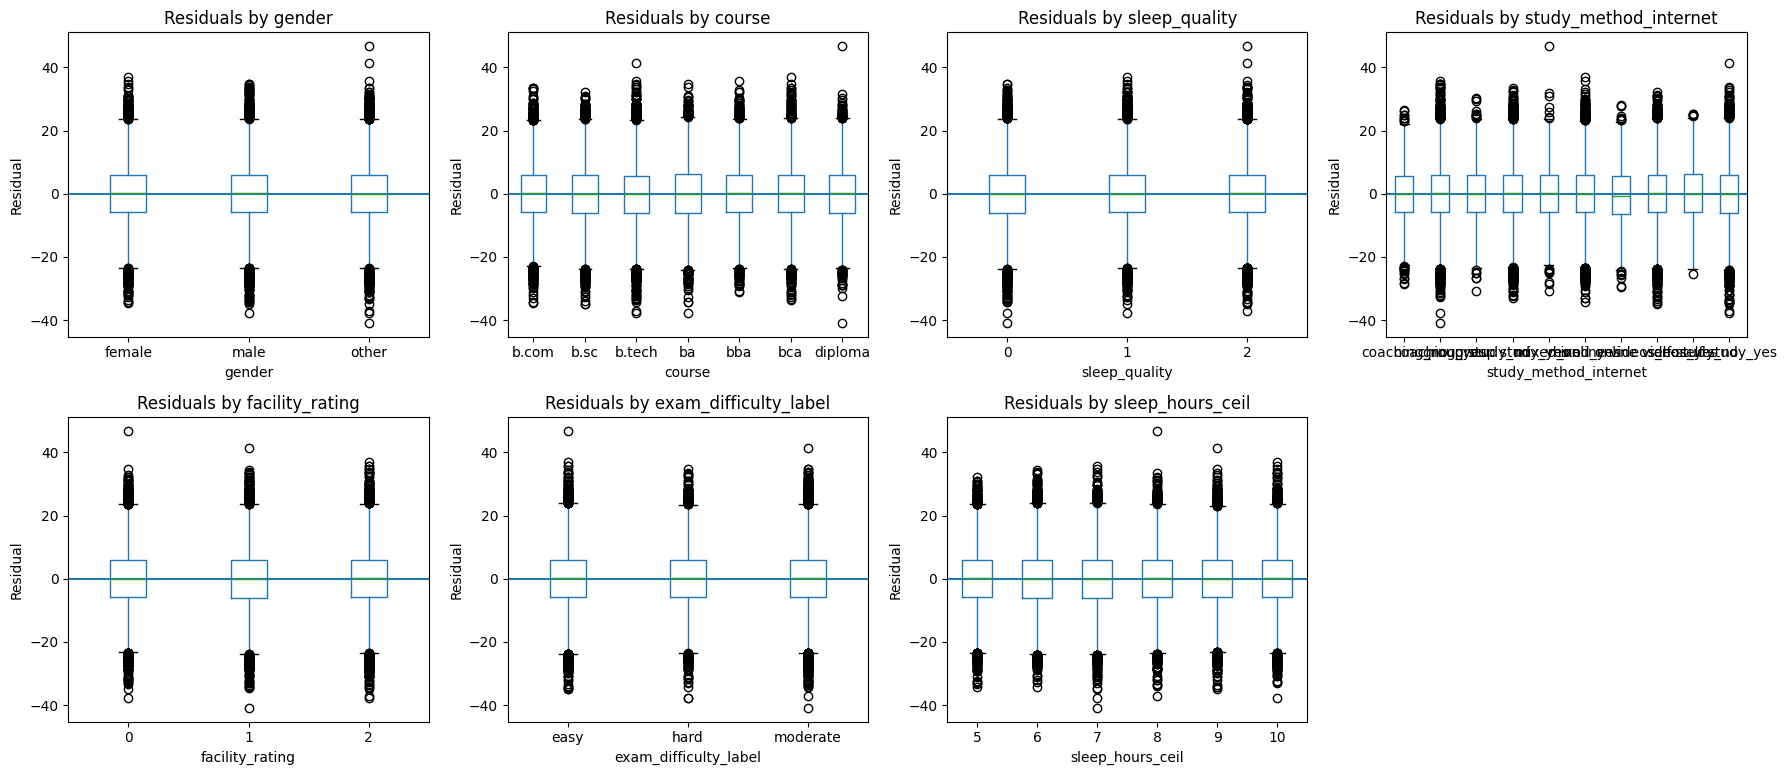

In [73]:

categorical_cols = [
    "gender",
    "course",
    # "internet_access",
    "sleep_quality",
    # "study_method",
    "study_method_internet",
    "facility_rating",
    "exam_difficulty_label",
    "sleep_hours_ceil"
]

n_cols = 4
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows),
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    
    res_df.boxplot(
        column="residual",
        by=col,
        ax=ax,
        grid=False,
    )
    
    ax.axhline(0)
    ax.set_title(f"Residuals by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Residual")

# Turn off unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("")  # remove pandas default title ONCE
plt.tight_layout()
plt.show()


In [52]:
res_df.columns

Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'actual', 'predicted', 'residual',
       'abs_residual', 'exam_difficulty_label', 'attendance_bin'],
      dtype='object')

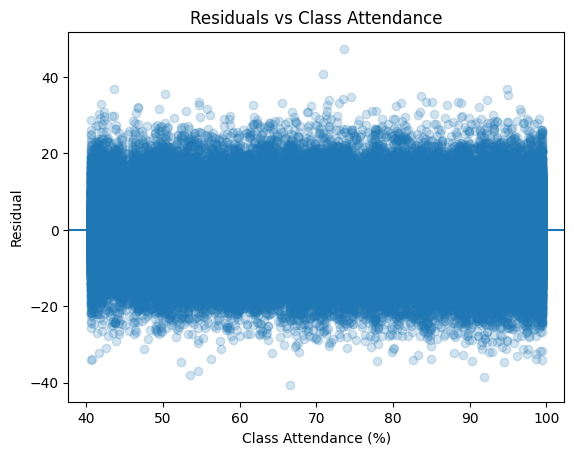

In [30]:
plt.figure()
plt.scatter(res_df["class_attendance"], residuals, alpha=0.2)
plt.axhline(0)
plt.xlabel("Class Attendance (%)")
plt.ylabel("Residual")
plt.title("Residuals vs Class Attendance")
plt.show()


In [31]:
group_error = (
    res_df
    .groupby(["study_method", "internet_access"])["residual"]
    .mean()
    .reset_index()
)

print(group_error.sort_values("residual"))


    study_method internet_access  residual
0       coaching              no -0.377186
6  online videos              no -0.311896
5          mixed             yes -0.094135
2    group study              no -0.055941
9     self-study             yes -0.018246
8     self-study              no  0.028635
7  online videos             yes  0.065177
1       coaching             yes  0.067416
3    group study             yes  0.112737
4          mixed              no  0.139066


C:\Users\16yas\AppData\Local\Temp\ipykernel_16776\3467181187.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["study_method", "internet_access"])["residual"]


In [32]:
res_df.sort_values("abs_residual", ascending=False).head(10)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,actual,predicted,residual,abs_residual,exam_difficulty_label
553891,21,other,diploma,1.73,73.6,no,7.5,2,mixed,0,0,100.000,52.685711,47.314289,47.314289,easy
87444,18,other,b.tech,2.85,70.9,yes,8.8,2,self-study,1,1,100.000,59.192709,40.807291,40.807291,moderate
199720,24,other,diploma,3.82,66.5,yes,6.7,0,coaching,1,1,19.599,60.176769,-40.577769,40.577769,moderate
450474,18,male,ba,6.03,91.9,yes,9.1,1,coaching,0,2,48.500,87.096671,-38.596671,38.596671,hard
354978,24,other,b.tech,7.32,53.5,yes,7.3,2,self-study,2,1,45.800,83.670238,-37.870238,37.870238,moderate
629254,17,other,b.tech,6.10,54.5,yes,6.3,0,self-study,2,2,26.800,63.761075,-36.961075,36.961075,hard
308258,22,female,bca,0.59,94.9,yes,9.2,1,mixed,2,0,93.300,56.355288,36.944712,36.944712,easy
479255,24,female,bba,0.08,43.6,yes,6.2,2,mixed,2,0,74.300,37.582951,36.717049,36.717049,easy
298935,20,male,bca,1.91,50.3,yes,9.7,1,coaching,2,2,91.200,55.788135,35.411865,35.411865,hard
572316,20,male,b.tech,0.08,95.0,yes,8.6,0,coaching,0,1,83.700,48.322111,35.377889,35.377889,moderate


C:\Users\16yas\AppData\Local\Temp\ipykernel_16776\621298184.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("attendance_bin")["abs_residual"]


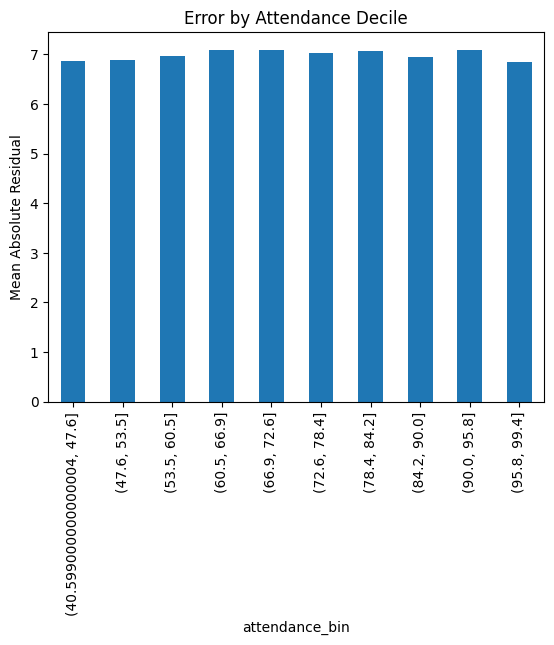

In [33]:
res_df["attendance_bin"] = pd.qcut(
    res_df["class_attendance"], q=10, duplicates="drop"
)

decile_error = (
    res_df
    .groupby("attendance_bin")["abs_residual"]
    .mean()
)

decile_error.plot(kind="bar")
plt.ylabel("Mean Absolute Residual")
plt.title("Error by Attendance Decile")
plt.show()


In [36]:
residuals

array([-9.71012433,  3.94523055, 18.07327417, ..., -2.49909499,
        0.79918862,  6.99176094], shape=(126000,))

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

eda = train.copy()

eda = preprocessing(eda)
ccols = ["age", "study_hours", "class_attendance", "sleep_hours", "sleep_quality", "facility_rating", "exam_difficulty", "exam_score"]

plt.figure(figsize=(18, 15))
sns.heatmap(eda[ccols], annot=True, cmap="coolwarm")
plt.show()


In [89]:
eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   id                     630000 non-null  int64   
 1   age                    630000 non-null  int64   
 2   gender                 630000 non-null  category
 3   course                 630000 non-null  category
 4   study_hours            630000 non-null  float64 
 5   class_attendance       630000 non-null  float64 
 6   sleep_hours            630000 non-null  float64 
 7   sleep_quality          630000 non-null  int64   
 8   facility_rating        630000 non-null  int64   
 9   exam_difficulty        630000 non-null  int64   
 10  exam_score             630000 non-null  float64 
 11  study_method_internet  630000 non-null  category
dtypes: category(3), float64(4), int64(5)
memory usage: 45.1 MB


### Training 3 Different Models w.r.t exam type

In [25]:
new_df = train.copy()
new_df = new_df.drop(columns="id")
new_df = preprocessing(new_df.copy())


train_df, test_df = train_test_split(
    new_df, test_size=0.2, random_state=42
)

category_col = "exam_difficulty"
target_col = "exam_score"


params = {
    "objective": "regression",
    "metric": "rmse",

    # learning dynamics
    "learning_rate": 0.035,        # slower, smoother
    "num_boost_round": 5000,        # compensate with depth in time

    # tree capacity
    "num_leaves": 64,              # enough to model interactions cleanly
    "max_depth": -1,
    "min_data_in_leaf": 120,       # critical for tail stability

    # regularization (this is where the improvement really comes from)
    "lambda_l2": 3.0,              # stronger shrinkage = calmer extremes
    "lambda_l1": 0.0,
    "min_gain_to_split": 0.1,      # prevents low-value splits

    # sampling
    "feature_fraction": 0.75,      # forces generalization
    "bagging_fraction": 0.8,
    "bagging_freq": 5,

    # misc
    "verbosity": -1,
    "seed": 42,
}

models = {}
test_predictions = []

for category in train_df[category_col].unique():
    # Split data by category
    train_subset = train_df[train_df[category_col] == category]
    test_subset = test_df[test_df[category_col] == category]

    X_train = train_subset[[i for i in new_df.columns if i!=target_col]]
    y_train = train_subset[target_col]

    X_test = test_subset[[i for i in new_df.columns if i!=target_col]]
    y_test = test_subset[target_col]

    # Train model
    model = lgb.LGBMRegressor(**params)
    
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

    # Predict
    preds = model.predict(X_test, num_iteration=model.best_iteration_)

    # Store predictions with index
    preds_df = pd.DataFrame({
        "index": test_subset.index,
        "y_true": y_test,
        "y_pred": preds
    })

    test_predictions.append(preds_df)
    models[category] = model

# Combine predictions from all models
final_preds = pd.concat(test_predictions).sort_values("index")

rmse = root_mean_squared_error(
    final_preds["y_true"],
    final_preds["y_pred"]
)

print(f"Overall RMSE: {rmse:.4f}")


Overall RMSE: 8.9229


In [26]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Drop identifier
df = train.copy()
df = df.drop(columns=["id"])

def preprocessing(data):
    df = data.copy()
    # Ordinal encodings (EXPLICIT)
    df["sleep_quality"] = df["sleep_quality"].map(
        {"poor": 0, "average": 1, "good": 2}
    )

    df["facility_rating"] = df["facility_rating"].map(
        {"low": 0, "medium": 1, "high": 2}
    )

    df["exam_difficulty"] = df["exam_difficulty"].map(
        {"easy": 0, "moderate": 1, "hard": 2}
    )

    # Explicit interaction
    df["study_method_internet"] = (
        df["study_method"].astype(str)
        + "_"
        + df["internet_access"].astype(str)
    ).astype("category")

    # Drop originals to avoid redundancy
    df = df.drop(columns=["study_method", "internet_access"])

    # df["study_internet"] = df["study_method"] + "_" + df["internet_access"]

    # df = df.drop(columns=["study_method", "internet_access"])

    categorical_cols = [
        "gender",
        "course",
        "study_method_internet",
        # "internet_access",
        # "study_method",
        # "study_internet",
        # "sleep_quality",
        # "facility_rating",
        # "exam_difficulty"
    ]

    for col in categorical_cols:
        df[col] = df[col].astype("category")
    


    # df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

X = preprocessing(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


train_data = lgb.Dataset(
    X_train,
    label=y_train,
    # categorical_feature=categorical_cols,
    free_raw_data=False
)

valid_data = lgb.Dataset(
    X_test,
    label=y_test,
    # categorical_feature=categorical_cols,
    reference=train_data,
    free_raw_data=False
)


params = {
    "objective": "regression",
    "metric": "huber",

    # learning dynamics
    "learning_rate": 0.05,
    "num_boost_round": 1000,

    # tree structure
    "num_leaves": 63,          # allow interactions, but not chaos
    "max_depth": -1,           # let leaves control depth
    "min_data_in_leaf": 400,   # stabilizes tails (important for you)

    # regularization
    "lambda_l1": 1.0,
    "lambda_l2": 0.0,          # gentle smoothing
    "min_gain_to_split": 0.0,

    # sampling
    "feature_fraction": 0.85,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,

    # misc
    "verbosity": 1,
    "seed": 42,
}


lgb_model = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    num_boost_round=500,
)

y_pred = lgb_model.predict(
    X_test, num_iteration=lgb_model.best_iteration
)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012650 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 601
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 10
[LightGBM] [Info] Start training from score 62.482335
MAE: 6.969546302362913
RMSE: 8.747752936772317
R2: 0.7848339843724511


In [13]:
dir(lgb_model)
lgb_model.num_trees()

1000

In [ ]:
MAE: 6.972559242003108
RMSE: 8.750459042579209
R2: 0.784700841136803

In [14]:
eda = train.copy()

In [27]:
res_df = train.copy()
res_df["predicte_score"] = lgb_model.predict(X)
res_df["residuals"] = train["exam_score"] - lgb_model.predict(X)
res_df["residuals"] = res_df["residuals"].abs()

In [28]:
res_df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,predicte_score,residuals
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3,86.862145,8.562145
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7,64.207083,17.507083
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0,74.564170,24.435830
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9,47.655515,16.244485
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0,94.340542,5.659458


In [17]:
res_df.sort_values(by="residuals", ascending=False).head(20)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,predicte_score,residuals
553891,553891,21,other,diploma,1.73,73.6,no,7.5,good,mixed,low,easy,100.000,54.184864,45.815136
78392,78392,20,other,b.com,0.86,90.9,yes,5.2,good,online videos,high,moderate,100.000,55.273015,44.726985
428160,428160,19,male,b.sc,0.08,43.7,yes,6.4,average,group study,medium,moderate,72.600,28.200153,44.399847
613957,613957,20,female,bca,0.08,97.0,yes,5.0,poor,coaching,high,moderate,92.900,51.002294,41.897706
47775,47775,17,female,b.com,0.75,89.4,yes,4.1,average,online videos,high,easy,88.800,47.157767,41.642233
526766,526766,21,other,b.sc,1.01,72.9,no,9.3,average,mixed,medium,easy,93.600,52.397816,41.202184
199720,199720,24,other,diploma,3.82,66.5,yes,6.7,poor,coaching,medium,moderate,19.599,60.745176,41.146176
87444,87444,18,other,b.tech,2.85,70.9,yes,8.8,good,self-study,medium,moderate,100.000,58.855115,41.144885
93901,93901,19,other,bba,1.96,85.0,yes,8.0,poor,self-study,high,hard,93.000,52.301349,40.698651
51537,51537,21,male,bca,0.47,82.7,yes,9.2,good,coaching,medium,moderate,100.000,59.375138,40.624862


In [46]:
dir(lgb_model)
lgb_model.trees_to_dataframe()

,tree_index,node_depth,node_index,left_child,right_child,parent_index,split_feature,split_gain,threshold,decision_type,missing_direction,missing_type,value,weight,count
0,0,1,0-S0,0-S2,0-S1,None,class_attendance,1.399430e+07,65.25,<=,left,None,62.481600,403211,403211
1,0,2,0-S2,0-S11,0-S4,0-S0,sleep_quality,2.533830e+06,0.0,<=,left,None,62.101200,151152,151152
2,0,3,0-S11,0-S27,0-S19,0-S2,study_method_internet,5.510780e+05,0||1||4||5,==,right,None,61.819200,52154,52154
3,0,4,0-S27,0-S47,0-S36,0-S11,sleep_hours,1.638030e+05,6.15,<=,left,None,62.022100,20492,20492
4,0,5,0-S47,0-L0,0-L48,0-S27,facility_rating,7.890730e+04,0.0,<=,left,None,61.835000,7460,7460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,999,11,999-S60,999-L59,999-L61,999-S59,study_method_internet,4.798160e+02,1||3||8,==,right,None,0.047198,264,264
124996,999,12,999-L59,None,None,999-S60,None,NaN,None,None,None,None,-0.030554,115,115
124997,999,12,999-L61,None,None,999-S60,None,NaN,None,None,None,None,0.102233,149,149
124998,999,11,999-L60,None,None,999-S59,None,NaN,None,None,None,None,-0.013694,2281,2281


In [ ]:
graph = lgb.create_tree_digraph(lgb_model, tree_index=0)
graph


In [18]:
print(cat_cols)
print(eda.columns)

['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']
Index(['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')


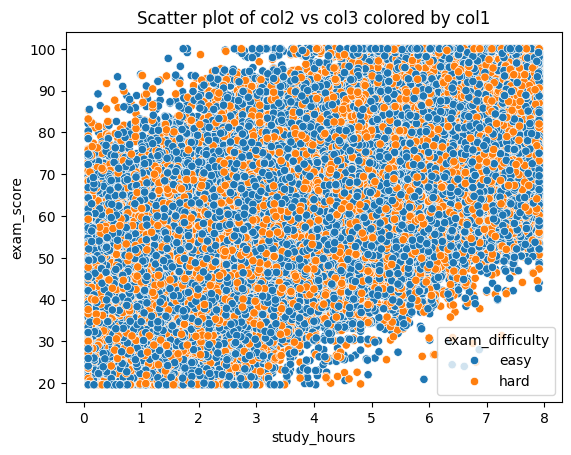

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=eda[eda["exam_difficulty"].isin(["easy","hard"])],
    x="study_hours",      # numerical feature
    y="exam_score",      # target
    hue="exam_difficulty",    # categorical column
    palette="tab10"
)

plt.title("Scatter plot of col2 vs col3 colored by col1")
plt.show()


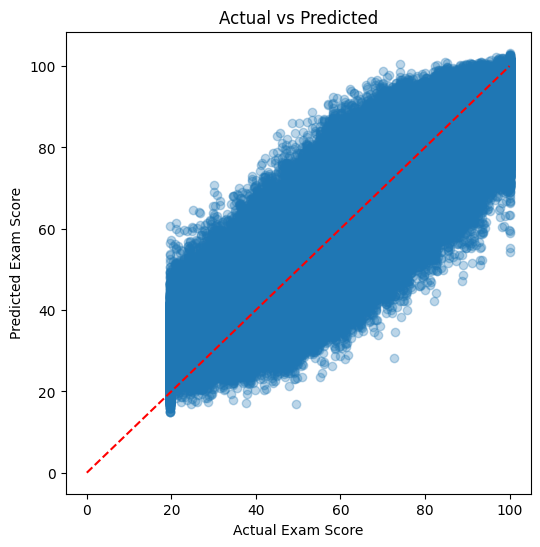

In [52]:

plt.figure(figsize=(6, 6))
plt.scatter(res_df["exam_score"], res_df["predicte_score"], alpha=0.3)
plt.plot([0, 100], [0, 100], color="red", linestyle="--")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted")
plt.show()


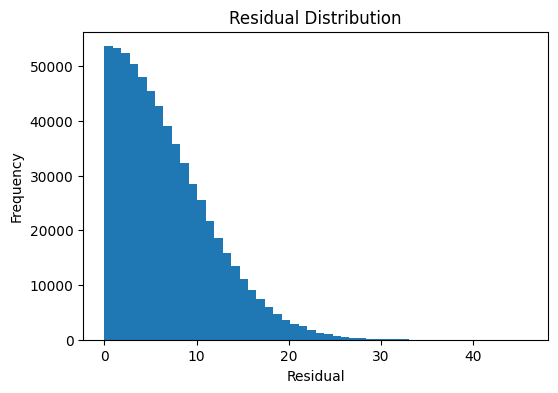

In [54]:
plt.figure(figsize=(6, 4))
plt.hist(res_df["residuals"], bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()


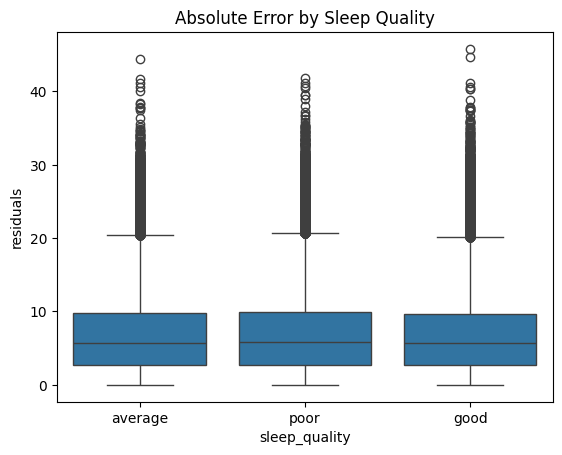

In [55]:
import seaborn as sns

sns.boxplot(
    data=res_df,
    x="sleep_quality",
    y="residuals"
)
plt.title("Absolute Error by Sleep Quality")
plt.show()


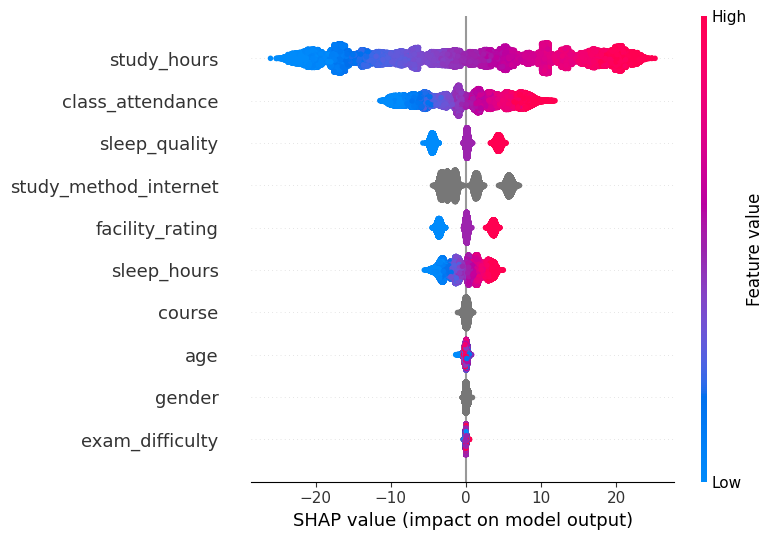

In [56]:
import shap

explainer = shap.TreeExplainer(lgb_model)
X_sample = X[:50000]
shap_values = explainer.shap_values(X_sample)  # sample ~50k rows

shap.summary_plot(shap_values, X_sample)


In [59]:
np.std(res_df.residuals)
np.max(res_df.residuals)
np.min(res_df.residuals)

np.float64(5.034468060216568e-06)

<Axes: ylabel='residuals'>

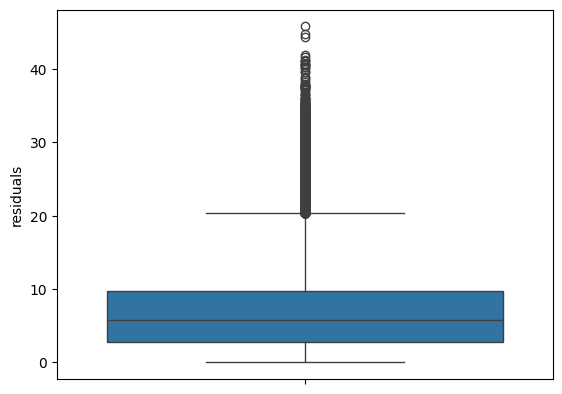

In [60]:
sns.boxplot(res_df.residuals)

In [65]:
res_df[res_df.residuals > 9.795251]

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,predicte_score,residuals
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7,63.324308,16.624308
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0,74.352434,24.647566
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9,47.539790,16.360210
6,6,20,male,b.sc,4.28,87.0,no,9.1,average,mixed,high,moderate,63.4,76.250913,12.850913
7,7,22,female,ba,4.19,44.9,yes,8.8,good,self-study,high,hard,76.8,61.973239,14.826761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629980,629980,21,male,bca,3.60,88.0,yes,9.4,poor,group study,low,moderate,42.5,61.074685,18.574685
629981,629981,17,female,b.com,1.88,54.1,yes,5.4,poor,coaching,low,easy,24.9,40.231182,15.331182
629983,629983,17,female,bca,0.23,99.4,yes,9.4,average,self-study,medium,hard,34.8,49.060875,14.260875
629991,629991,24,other,bba,5.95,70.3,yes,5.0,average,self-study,low,hard,44.2,64.120880,19.920880


In [68]:
(res_df[res_df.residuals > 10]).shape[0]/res_df.shape[0]

0.2401095238095238

In [69]:
q4 = res_df[res_df.residuals > 9.795251]

In [72]:
q4.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score,predicte_score,residuals
count,157500.000000,157500.000000,157500.000000,157500.000000,157500.000000,157500.000000,157500.000000,157500.000000
mean,315332.269295,20.537244,3.922030,72.068095,7.069165,61.862588,62.003661,14.061341
std,182079.388776,2.257170,2.340637,17.234029,1.737855,21.277664,15.985877,3.726539
min,1.000000,17.000000,0.080000,40.600000,4.100000,19.599000,16.792011,9.795383
25%,157435.000000,19.000000,1.870000,57.400000,5.600000,46.400000,49.234754,11.213151
50%,315387.000000,21.000000,3.870000,72.600000,7.100000,61.900000,62.271463,13.067825
75%,472672.250000,23.000000,5.980000,87.000000,8.600000,77.500000,75.069958,15.909451
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000,100.970675,45.815136


In [73]:
for i in cat_cols:
    print("-"*20)
    print(q4[i].value_counts())
    

--------------------
gender
other     52820
male      52539
female    52141
Name: count, dtype: int64
--------------------
course
b.tech     32645
b.sc       27934
b.com      26951
bca        22603
bba        18948
ba         15656
diploma    12763
Name: count, dtype: int64
--------------------
internet_access
yes    145446
no      12054
Name: count, dtype: int64
--------------------
sleep_quality
poor       54642
good       51992
average    50866
Name: count, dtype: int64
--------------------
study_method
self-study       33882
coaching         32617
group study      30393
mixed            30341
online videos    30267
Name: count, dtype: int64
--------------------
facility_rating
medium    54439
low       51837
high      51224
Name: count, dtype: int64
--------------------
exam_difficulty
moderate    88480
easy        44260
hard        24760
Name: count, dtype: int64


In [79]:
res_df["exam_difficulty"].value_counts()

exam_difficulty
moderate    353982
easy        176540
hard         99478
Name: count, dtype: int64

In [77]:
q4["exam_difficulty"].value_counts()

exam_difficulty
moderate    88480
easy        44260
hard        24760
Name: count, dtype: int64

In [80]:
(353982 - 88480)/353982

0.7500437875372195

In [81]:
(176540 - 44260)/176540

0.7492919451682338

In [82]:
q20 = res_df[res_df.residuals > 20]

In [83]:
q20.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score,predicte_score,residuals
count,12510.000000,12510.000000,12510.000000,12510.000000,12510.000000,12510.000000,12510.000000,12510.000000
mean,314315.313429,20.532294,3.787888,73.163384,7.072862,61.226219,61.686615,23.017781
std,181042.669893,2.253757,2.285860,17.190300,1.731166,24.253275,14.588102,2.882638
min,2.000000,17.000000,0.080000,40.600000,4.100000,19.599000,16.792011,20.000335
25%,157018.000000,19.000000,1.810000,58.800000,5.600000,40.200000,50.260017,20.945526
50%,313178.000000,21.000000,3.620000,74.150000,7.000000,61.600000,61.482018,22.147914
75%,468594.500000,23.000000,5.810000,88.500000,8.600000,82.000000,73.129154,24.208319
max,629922.000000,24.000000,7.910000,99.400000,9.900000,100.000000,100.569009,45.815136


In [87]:
for i in cat_cols:
    print("-"*20)
    print(q20[i].value_counts())

--------------------
gender
other     4235
female    4147
male      4128
Name: count, dtype: int64
--------------------
course
b.tech     2619
b.sc       2173
b.com      2064
bca        1817
bba        1524
ba         1277
diploma    1036
Name: count, dtype: int64
--------------------
internet_access
yes    11617
no       893
Name: count, dtype: int64
--------------------
sleep_quality
poor       4442
good       4184
average    3884
Name: count, dtype: int64
--------------------
study_method
self-study       2816
coaching         2729
online videos    2409
group study      2353
mixed            2203
Name: count, dtype: int64
--------------------
facility_rating
medium    4423
high      4260
low       3827
Name: count, dtype: int64
--------------------
exam_difficulty
moderate    7117
easy        3479
hard        1914
Name: count, dtype: int64


In [86]:
train.internet_access.value_counts()

internet_access
yes    579423
no      50577
Name: count, dtype: int64

NameError: name 'res_df' is not defined

<Axes: xlabel='residuals', ylabel='facility_rating'>

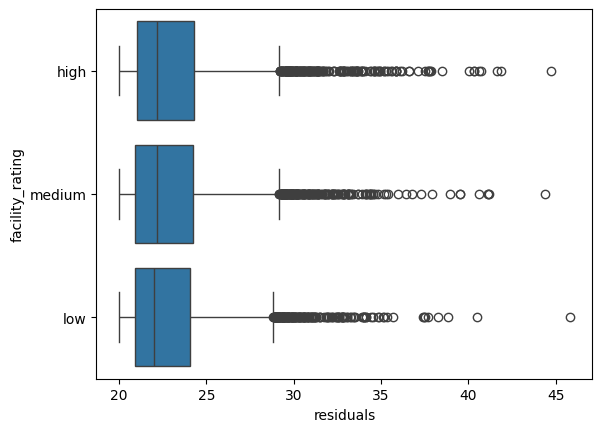

In [89]:
sns.boxplot(data=q20, x="residuals", y="facility_rating")

In [91]:
q20.sort_values(by='residuals', ascending=False).head(50)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,predicte_score,residuals
553891,553891,21,other,diploma,1.73,73.6,no,7.5,good,mixed,low,easy,100.000,54.184864,45.815136
78392,78392,20,other,b.com,0.86,90.9,yes,5.2,good,online videos,high,moderate,100.000,55.273015,44.726985
428160,428160,19,male,b.sc,0.08,43.7,yes,6.4,average,group study,medium,moderate,72.600,28.200153,44.399847
613957,613957,20,female,bca,0.08,97.0,yes,5.0,poor,coaching,high,moderate,92.900,51.002294,41.897706
47775,47775,17,female,b.com,0.75,89.4,yes,4.1,average,online videos,high,easy,88.800,47.157767,41.642233
526766,526766,21,other,b.sc,1.01,72.9,no,9.3,average,mixed,medium,easy,93.600,52.397816,41.202184
199720,199720,24,other,diploma,3.82,66.5,yes,6.7,poor,coaching,medium,moderate,19.599,60.745176,41.146176
87444,87444,18,other,b.tech,2.85,70.9,yes,8.8,good,self-study,medium,moderate,100.000,58.855115,41.144885
93901,93901,19,other,bba,1.96,85.0,yes,8.0,poor,self-study,high,hard,93.000,52.301349,40.698651
51537,51537,21,male,bca,0.47,82.7,yes,9.2,good,coaching,medium,moderate,100.000,59.375138,40.624862


'tree\nversion=v4\nnum_class=1\nnum_tree_per_iteration=1\nlabel_index=0\nmax_feature_idx=9\nobjective=regression\nfeature_names=age gender course study_hours class_attendance sleep_hours sleep_quality facility_rating exam_difficulty study_method_internet\nfeature_infos=[17:24] -1:1:2:0 -1:2:1:0:5:4:3:6 [0.080000000000000002:7.9100000000000001] [40.600000000000001:99.400000000000006] [4.0999999999999996:9.9000000000000004] [0:2] [0:2] [0:2] -1:1:9:3:5:7:8:0:4:2:6\ntree_sizes=5620 5753 5734 5712 5751 5727 5756 5751 5710 5862 5785 5721 5700 5774 5715 5723 5679 5713 5681 5726 5705 5757 5788 5777 5787 5860 5757 5860 5750 5716 5763 5740 5729 5771 5778 5772 5774 5804 5807 5851 5774 5838 5826 5789 5762 5792 5787 5768 5780 5793 5808 5852 5829 5772 5801 5787 5837 5842 5808 5837 5781 5833 5854 5826 5819 5793 5824 5809 5842 5789 5826 5903 5864 5816 5795 5864 5894 5785 5866 5891 5823 5868 5817 5803 5933 5838 5833 5789 5827 5811 5899 5811 5844 5794 5881 5824 5747 5758 5731 5667 5819 5797 5826 5738 5

In [99]:
eda = train.copy()

<Axes: xlabel='edxfr', ylabel='exam_score'>

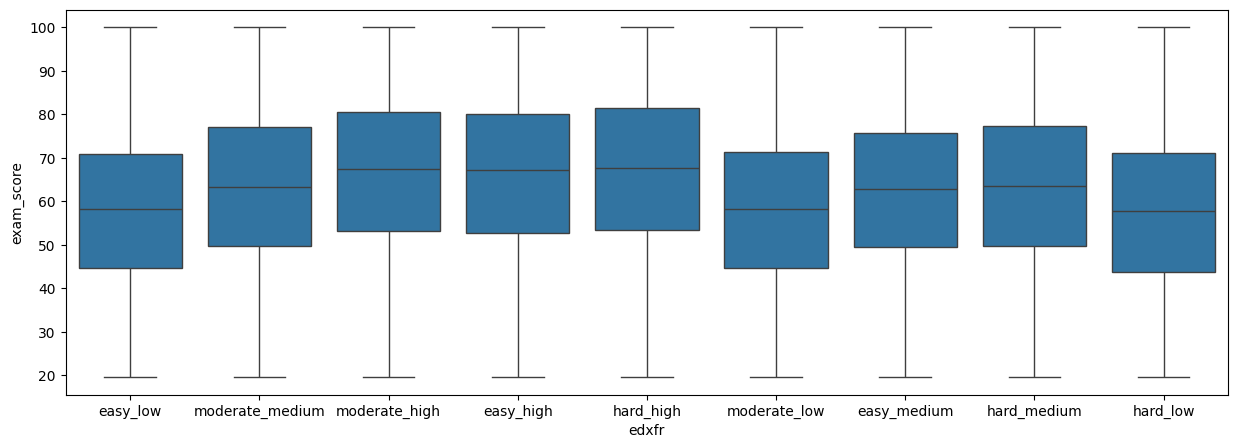

In [ ]:
eda["edxfr"] = eda.exam_difficulty + '_' + eda.facility_rating
plt.figure(figsize=(15,5))
sns.boxplot(data=eda, x='edxfr', y="exam_score")

In [ ]:
q20["edxsq"] = q20.exam_difficulty + '_' + q20.sleep_quality
q20["edxfr"] = q20.exam_difficulty + '_' + q20.facility_rating

In [ ]:
from dtreeviz.trees import dtreeviz

viz = dtreeviz(
    lgb_model.booster_,
    X_train,
    y_train,
    tree_index=0,
    feature_names=X_train.columns,
    target_name="exam_score"
)

viz.save("lgbm_tree.html")


In [20]:
import dtreeviz


In [1]:
from dtreeviz import dtreeviz
import lightgbm as lgb
import os

booster = lgb_model

os.makedirs("trees", exist_ok=True)

html_blocks = []

for i in range(booster.num_trees()):
    viz = dtreeviz(
        booster,
        X_train,
        y_train,
        tree_index=i,
        feature_names=X_train.columns,
        target_name="target"
    )

    tree_html = f"trees/tree_{i}.html"
    viz.save(tree_html)

    with open(tree_html, "r", encoding="utf-8") as f:
        html_blocks.append(f"""
        <section class="tree">
            <h2>Tree {i}</h2>
            {f.read()}
        </section>
        """)


NameError: name 'lgb_model' is not defined

In [24]:
dir(lgb_model)
lgb_model._Booster__boost()

TypeError: Booster.__boost() missing 2 required positional arguments: 'grad' and 'hess'

In [29]:
res_df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score,predicte_score,residuals
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,6.300000e+05
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672,62.501467,6.825031e+00
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884,16.789974,5.176790e+00
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000,14.282118,1.547308e-07
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000,49.385213,2.723263e+00
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000,62.852701,5.765024e+00
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000,75.457721,9.815564e+00
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000,103.983682,4.639773e+01


In [30]:
q20 = res_df[res_df.residuals > 20]

In [32]:
q20.reset_index()

,index,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,predicte_score,residuals
0,2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0,74.564170,24.435830
1,45,45,17,male,b.tech,3.11,58.3,yes,6.4,poor,group study,high,hard,70.0,49.418615,20.581385
2,104,104,24,male,b.sc,2.69,62.7,yes,6.3,average,mixed,medium,hard,29.6,52.033949,22.433949
3,393,393,18,male,diploma,4.54,65.3,yes,4.5,poor,group study,medium,moderate,33.6,55.768725,22.168725
4,439,439,22,female,b.sc,4.86,43.6,yes,6.0,average,coaching,low,moderate,89.1,60.766944,28.333056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12733,629830,629830,19,other,b.com,6.33,42.6,yes,7.9,average,self-study,high,hard,92.9,67.347762,25.552238
12734,629834,629834,22,female,bba,2.23,50.9,yes,4.8,good,mixed,medium,moderate,23.7,48.571590,24.871590
12735,629922,629922,24,female,b.sc,5.36,85.4,yes,5.2,average,self-study,high,moderate,95.2,73.040959,22.159041
12736,629941,629941,21,other,bba,6.10,53.6,yes,6.7,poor,mixed,low,moderate,42.7,62.787758,20.087758


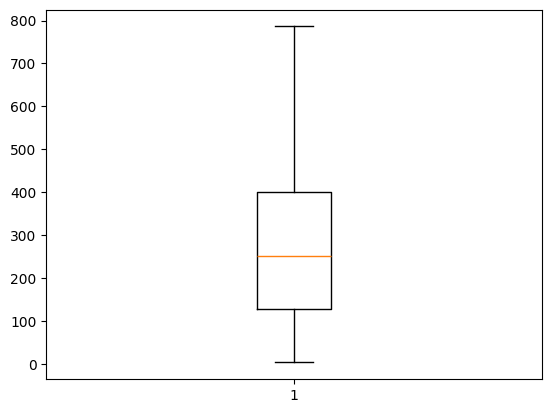

In [35]:
plt.boxplot(q20.study_hours * q20.class_attendance)
plt.show()

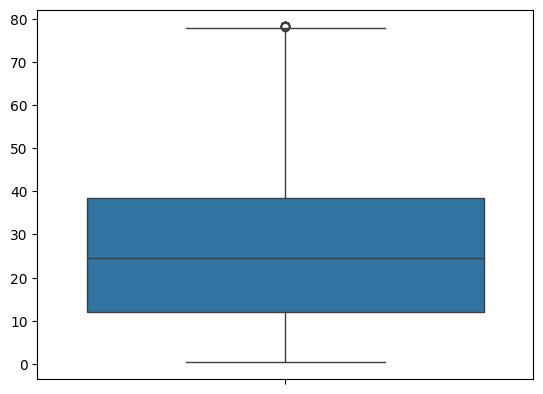

In [37]:
sns.boxplot(q20.study_hours * q20.sleep_hours)
plt.show()

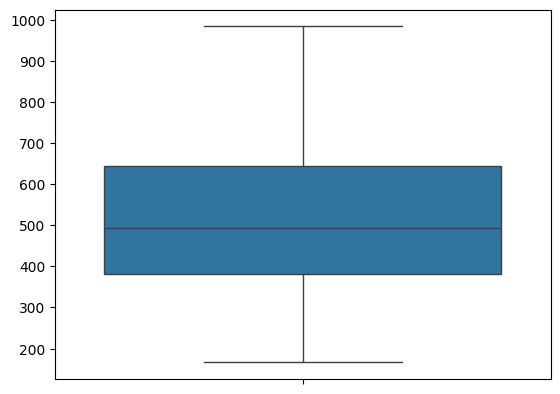

In [38]:
sns.boxplot(q20.class_attendance * q20.sleep_hours)
plt.show()

<Axes: >

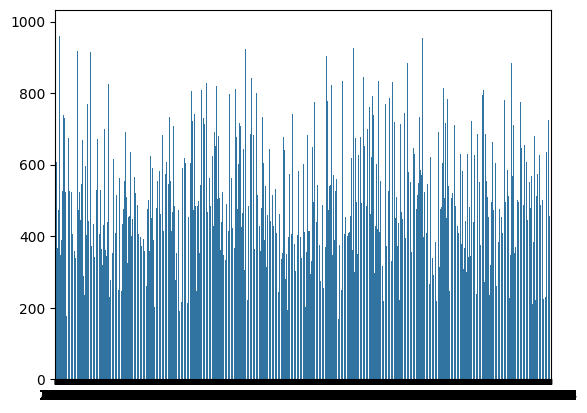

In [48]:
sns.barplot((q20.class_attendance * q20.sleep_hours).round(100))

In [42]:
dir(sns)

['FacetGrid',
 'JointGrid',
 'PairGrid',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_base',
 '_compat',
 '_core',
 '_docstrings',
 '_orig_rc_params',
 '_statistics',
 '_stats',
 'algorithms',
 'axes_style',
 'axisgrid',
 'barplot',
 'blend_palette',
 'boxenplot',
 'boxplot',
 'categorical',
 'catplot',
 'choose_colorbrewer_palette',
 'choose_cubehelix_palette',
 'choose_dark_palette',
 'choose_diverging_palette',
 'choose_light_palette',
 'clustermap',
 'cm',
 'color_palette',
 'colors',
 'countplot',
 'crayon_palette',
 'crayons',
 'cubehelix_palette',
 'dark_palette',
 'desaturate',
 'despine',
 'displot',
 'distplot',
 'distributions',
 'diverging_palette',
 'dogplot',
 'ecdfplot',
 'external',
 'get_data_home',
 'get_dataset_names',
 'heatmap',
 'histplot',
 'hls_palette',
 'husl_palette',
 'jointplot',
 'kdeplot',
 'light_palette',
 'lineplot',
 'lmplot',
 'load_dataset',
 'matrix

In [ ]:
        X['study_effectiveness_score'] = (
            X['study_hours'] * 
            X['study_method'].map(self.study_method_efficiency) *  # Method efficiency
            (X['class_attendance'] / 100)  # Consistency
        )
        
        # 2. Sleep Quality Weighted Hours
        X['sleep_quality_weighted_hours'] = (
            X['sleep_quality'].map(self.sleep_quality_map) * 
            X['sleep_hours']
        )
        
        # 3. Productive Awake Ratio (time management)
        awake_hours = 24 - X['sleep_hours']
        estimated_class_hours = 6 * (X['class_attendance'] / 100)
        total_productive_hours = X['study_hours'] + estimated_class_hours
        X['productive_awake_ratio'] = total_productive_hours / awake_hours

In [44]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Drop identifier
df = train.copy()
df = df.drop(columns=["id"])

def preprocessing(data):
    df = data.copy()
    # Ordinal encodings (EXPLICIT)
    df["sleep_quality"] = df["sleep_quality"].map(
        {"poor": 0, "average": 1, "good": 2}
    )

    df["facility_rating"] = df["facility_rating"].map(
        {"low": 0, "medium": 1, "high": 2}
    )

    df["exam_difficulty"] = df["exam_difficulty"].map(
        {"easy": 0, "moderate": 1, "hard": 2}
    )

    # Explicit interaction
    df["study_method_internet"] = (
        df["study_method"].astype(str)
        + "_"
        + df["internet_access"].astype(str)
    ).astype("category")

    sleep_quality_map = {'poor': 0, 'average': 1, 'good': 2}
    study_method_efficiency = {
        'coaching': 1.2, 'mixed': 1.1, 'group study': 1.0, 
        'online videos': 0.9, 'self-study': 0.8
    }

    df['study_effectiveness_score'] = (
        df['study_hours'] * 
        df['study_method'].map(study_method_efficiency) *  # Method efficiency
        (df['class_attendance'] / 100)  # Consistency
    )
    
    # 2. Sleep Quality Weighted Hours
    df['sleep_quality_weighted_hours'] = (
        df['sleep_quality'].map(sleep_quality_map) * 
        df['sleep_hours']
    )
    
    # 3. Productive Awake Ratio (time management)
    awake_hours = 24 - df['sleep_hours']
    estimated_class_hours = 6 * (df['class_attendance'] / 100)
    total_productive_hours = df['study_hours'] + estimated_class_hours
    df['productive_awake_ratio'] = total_productive_hours / awake_hours


    df['low_performer_indicator'] = ((df['study_hours'] < 3) & 
                                            (df['class_attendance'] < 70) &
                                            (df['study_method'] == 'self-study')).astype(int)

    df['high_performer_indicator'] = ((df['study_hours'] > 5) & 
                                            (df['class_attendance'] > 85) &
                                            (df['sleep_quality'] == 'good')).astype(int)

    # Create non-linear score range features
    df['score_risk_factor'] = (
        (df['study_hours'] < 2) * 2 +  # High risk for very low study
        (df['class_attendance'] < 60) * 1.5 +  # Risk for low attendance
        (df['study_method'] == 'self-study') * 1  # Risk for self-study
    )

    # Drop originals to avoid redundancy
    df = df.drop(columns=["study_method", "internet_access"])

    # df["study_internet"] = df["study_method"] + "_" + df["internet_access"]

    # df = df.drop(columns=["study_method", "internet_access"])

    categorical_cols = [
        "gender",
        "course",
        "study_method_internet",
        # "internet_access",
        # "study_method",
        # "study_internet",
        # "sleep_quality",
        # "facility_rating",
        # "exam_difficulty"
    ]

    for col in categorical_cols:
        df[col] = df[col].astype("category")
    


    # df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df

X = df.drop(columns=["exam_score"])
print("X cols before", X.columns)
y = df["exam_score"]

X = preprocessing(X)

print("X cols after", X.columns)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


train_data = lgb.Dataset(
    X_train,
    label=y_train,
    # categorical_feature=categorical_cols,
    free_raw_data=False
)

valid_data = lgb.Dataset(
    X_test,
    label=y_test,
    # categorical_feature=categorical_cols,
    reference=train_data,
    free_raw_data=False
)


params = {
    "objective": "regression",
    "metric": "rmse",

    # learning dynamics
    "learning_rate": 0.05,
    "num_boost_round": 3000,

    # tree structure
    "num_leaves": 63,          # allow interactions, but not chaos
    "max_depth": -1,           # let leaves control depth
    "min_data_in_leaf": 400,   # stabilizes tails (important for you)

    # regularization
    "lambda_l1": 1.0,
    "lambda_l2": 0.0,          # gentle smoothing
    "min_gain_to_split": 0.0,

    # sampling
    "feature_fraction": 0.85,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,

    # misc
    "verbosity": 1,
    "seed": 42,
    "early_stopping_rounds": 200,
}
lgbm_optimized = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'rmse',
    'n_estimators': 3000,              # More trees for better performance
    'learning_rate': 0.01,             # Lower learning rate with more trees
    'max_depth': -1,                    # Slightly deeper for complex interactions
    'num_leaves': 127,                  # 2^max_depth - 1 (but can be less)
    'subsample': 0.9,                  # Higher since you have lots of data
    'colsample_bytree': 0.85,
    'colsample_bynode': 0.7,           # Additional column sampling per split
    'reg_alpha': 1.0,                  # Lighter regularization
    'reg_lambda': 1.0,
    'min_child_samples': 50,           # Higher for more generalization
    'min_child_weight': 0.001,
    'min_split_gain': 0.0,
    'subsample_freq': 1,               # Apply subsample every iteration
    # 'feature_fraction': 0.9,           # Another name for colsample_bytree
    'bagging_fraction': 0.7,           # Another name for subsample
    'bagging_freq': 1,
    # 'cat_smooth': 10,                  # For categorical features
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 1,
    # 'importance_type': 'gain',         # Split gain as importance measure
    'early_stopping_roubds':200,
}

lgb_model = lgb.train(
    lgbm_optimized,
    train_data,
    valid_sets=[valid_data],
)

y_pred = lgb_model.predict(
    X_test, num_iteration=lgb_model.best_iteration
)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


X cols before Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')
X cols after Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'sleep_hours', 'sleep_quality', 'facility_rating', 'exam_difficulty',
       'study_method_internet', 'study_effectiveness_score',
       'sleep_quality_weighted_hours', 'productive_awake_ratio',
       'low_performer_indicator', 'high_performer_indicator',
       'score_risk_factor'],
      dtype='object')
[LightGBM] [Warning] Unknown parameter: early_stopping_roubds
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.9 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=1 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] Unknown parameter: early_stopping_roubds
[LightGBM] [Warning] bagging

<Axes: >

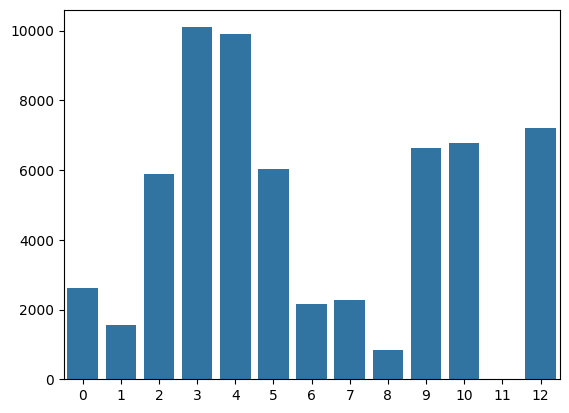

In [ ]:
sns.barplot(lgb_model.feature_importance())

<Axes: xlabel='importances', ylabel='features'>

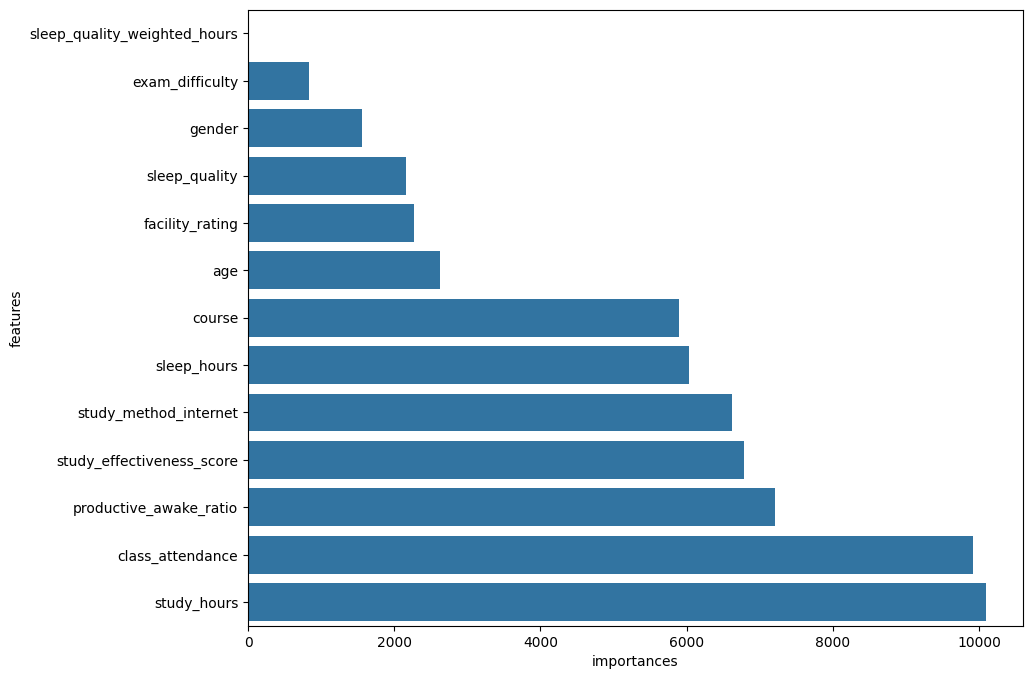

In [27]:
plt.figure(figsize=(10,8))
sns.barplot(data = pd.DataFrame({    
    "features":lgb_model.feature_name(),
    "importances": lgb_model.feature_importance(importance_type='split')
}).sort_values(by='importances'),
y = 'features',
x='importances'
)


In [25]:
X.columns

Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'sleep_hours', 'sleep_quality', 'facility_rating', 'exam_difficulty',
       'study_method_internet', 'study_effectiveness_score',
       'sleep_quality_weighted_hours', 'productive_awake_ratio'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Drop identifier
df = train.copy()
df = df.drop(columns=["id"])

def preprocessing(data):
    df = data.copy()
    # Ordinal encodings (EXPLICIT)
    df["sleep_quality"] = df["sleep_quality"].map(
        {"poor": 0, "average": 1, "good": 2}
    )

    df["facility_rating"] = df["facility_rating"].map(
        {"low": 0, "medium": 1, "high": 2}
    )

    df["exam_difficulty"] = df["exam_difficulty"].map(
        {"easy": 0, "moderate": 1, "hard": 2}
    )

    # Explicit interaction
    df["study_method_internet"] = (
        df["study_method"].astype(str)
        + "_"
        + df["internet_access"].astype(str)
    ).astype("category")

    sleep_quality_map = {'poor': 0, 'average': 1, 'good': 2}
    # study_method_efficiency = {
    #     'coaching': 1.2, 'mixed': 1.1, 'group study': 1.0, 
    #     'online videos': 0.9, 'self-study': 0.8
    # }

    # df['study_effectiveness_score'] = (
    #     df['study_hours'] * 
    #     df['study_method'].map(study_method_efficiency) *  # Method efficiency
    #     (df['class_attendance'] / 100)  # Consistency
    # )
    
    # 2. Sleep Quality Weighted Hours
    df['sleep_quality_weighted_hours'] = (
        df['sleep_quality'].map(sleep_quality_map) * 
        df['sleep_hours']
    )
    
    # 3. Productive Awake Ratio (time management)
    awake_hours = 24 - df['sleep_hours']
    # df['awake_hours'] = 24 - df['sleep_hours']
    estimated_class_hours = 6 * (df['class_attendance'] / 100)
    total_productive_hours = df['study_hours'] + estimated_class_hours
    # df['productive_awake_ratio'] = total_productive_hours / awake_hours


    # df['low_performer_indicator'] = ((df['study_hours'] < 3) & 
    #                                         (df['class_attendance'] < 70) &
    #                                         (df['study_method'] == 'self-study')).astype(int)

    # df['high_performer_indicator'] = ((df['study_hours'] > 5) & 
    #                                         (df['class_attendance'] > 85) &
    #                                         (df['sleep_quality'] == 'good')).astype(int)

    # Create non-linear score range features
    # df['score_risk_factor'] = (
    #     (df['study_hours'] < 2) * 2 +  # High risk for very low study
    #     (df['class_attendance'] < 60) * 1.5 +  # Risk for low attendance
    #     (df['study_method'] == 'self-study') * 1  # Risk for self-study
    # )

    # Drop originals to avoid redundancy
    # df = df.drop(columns=["study_method", "internet_access"])

    # df["study_internet"] = df["study_method"] + "_" + df["internet_access"]

    # df = df.drop(columns=["study_method", "internet_access"])

    categorical_cols = [
        "gender",
        "course",
        "study_method_internet",
        # "internet_access",
        "study_method",
        # "study_internet",
        # "sleep_quality",
        # "facility_rating",
        # "exam_difficulty"
    ]

    for col in categorical_cols:
        df[col] = df[col].astype("category")
    


    # df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df

X = df.drop(columns=["exam_score"])
print("X cols before", X.columns)
y = df["exam_score"]

X = preprocessing(X)
new_cols = ['study_hours', 'class_attendance', 'study_method_internet', 'study_method']
X = X[new_cols]

print("X cols after", X.columns)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


train_data = lgb.Dataset(
    X_train,
    label=y_train,
    # categorical_feature=categorical_cols,
    free_raw_data=False
)

valid_data = lgb.Dataset(
    X_test,
    label=y_test,
    # categorical_feature=categorical_cols,
    reference=train_data,
    free_raw_data=False
)


params = {
    "objective": "regression",
    "metric": "rmse",

    # learning dynamics
    "learning_rate": 0.05,
    "num_boost_round": 3000,

    # tree structure
    "num_leaves": 63,          # allow interactions, but not chaos
    "max_depth": -1,           # let leaves control depth
    "min_data_in_leaf": 400,   # stabilizes tails (important for you)

    # regularization
    "lambda_l1": 1.0,
    "lambda_l2": 0.0,          # gentle smoothing
    "min_gain_to_split": 0.0,

    # sampling
    "feature_fraction": 0.85,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,

    # misc
    "verbosity": 1,
    "seed": 42,
    "early_stopping_rounds": 200,
}

lgb_model = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
)

y_pred = lgb_model.predict(
    X_test, num_iteration=lgb_model.best_iteration
)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


X cols before Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')
X cols after Index(['study_hours', 'class_attendance', 'study_method_internet',
       'study_method'],
      dtype='object')
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003422 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 517
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 4
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[757]	valid_0's rmse: 10.1728
MAE: 8.146724331101433
RMSE: 10.172819994567627
R2: 0.7090198388818443


In [168]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Drop identifier
df = train.copy()
df = df.drop(columns=["id"])

def preprocessing(data):
    df = data.copy()
    # Ordinal encodings (EXPLICIT)
    # df["sleep_quality"] = df["sleep_quality"].map(
    #     {"poor": 0, "average": 1, "good": 2}
    # )

    # df["facility_rating"] = df["facility_rating"].map(
    #     {"low": 0, "medium": 1, "high": 2}
    # )

    # df["exam_difficulty"] = df["exam_difficulty"].map(
    #     {"easy": 0, "moderate": 1, "hard": 2}
    # )

    # Explicit interaction
    df["study_method_internet"] = (
        df["study_method"].astype(str)
        + "_"
        + df["internet_access"].astype(str)
    ).astype("category")

    df['awake_hours'] = 24 - df['sleep_hours']
    # df['class_hours'] = df['awake_hours'] - df['study_hours']

    # df['sleep_effectiveness'] = df['sleep_hours'] * df["sleep_quality"].map({"poor":0.5, "average": 1, "good": 1.5})
    df['study_effectiveness'] = df['awake_hours']/(df['study_hours'] + 0.001)
    # df['course_x_exam_diff'] = (df['course'].astype(str) + '_' + df['exam_difficulty'].astype(str)).astype('category')
    # df['low_performer_indicator'] = ((df['study_hours'] <= 2) & 
    #                                     (df['class_attendance'] <= 50) &
    #                                     # (df['study_method'].isin(['self-study'])) &
    #                                     (df['sleep_quality'] != 'good')).astype(int)

    # df['high_performer_indicator'] = ((df['study_hours'] > 5) & 
    #                                         (df['class_attendance'] > 80) &
    #                                         (df['sleep_quality'] == 'good')).astype(int)

    # Drop originals to avoid redundancy
    # df = df.drop(columns=["study_method", "internet_access"])

    # df = df.drop(columns=["study_method", "internet_access"])

    ohe_categorical_cols = [
        "internet_access",
        "exam_difficulty",
        "study_method",
        "facility_rating",
        # "sleep_quality"
    ]

    categorical_cols = [
        'sleep_quality',
        # 'facility_rating',
        'gender',
        'course',
        # 'study_method',
    ]

    for col in categorical_cols:
        df[col] = df[col].astype("category")
    
    # df = df.drop(columns=['exam_difficulty', 'course'])
    
    # df = df.drop(columns=categorical_cols)

    # One Hot Encoding
    df = pd.get_dummies(df, columns=ohe_categorical_cols, drop_first=True)

    return df

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

X = preprocessing(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


train_data = lgb.Dataset(
    X_train,
    label=y_train,
    # categorical_feature=categorical_cols,
    free_raw_data=False
)

valid_data = lgb.Dataset(
    X_test,
    label=y_test,
    # categorical_feature=categorical_cols,
    reference=train_data,
    free_raw_data=False
)


params = {
    "objective": "regression",
    "metric": "rmse",

    # learning dynamics
    "learning_rate": 0.05,
    "num_boost_round": 3000,

    # tree structure
    "num_leaves": 63,          # allow interactions, but not chaos
    "max_depth": -1,           # let leaves control depth
    "min_data_in_leaf": 100,   # stabilizes tails (important for you)

    # regularization
    "lambda_l1": 1.0,
    "lambda_l2": 0.0,          # gentle smoothing
    "min_gain_to_split": 0.0,

    # sampling
    "feature_fraction": 0.85,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,

    # misc
    "verbosity": 1,
    "seed": 42,
    "early_stopping_rounds": 150,
}


lgb_model = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    num_boost_round=500,
)

y_pred = lgb_model.predict(
    X_test, num_iteration=lgb_model.best_iteration
)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016739 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 930
[LightGBM] [Info] Number of data points in the train set: 441000, number of used features: 19
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 62.484815
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[904]	valid_0's rmse: 8.74653
MAE: 6.972903139117447
RMSE: 8.746529318307765
R2: 0.7852628357975429


In [68]:
X.columns

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours',
       'sleep_quality', 'facility_rating', 'exam_difficulty',
       'study_method_internet', 'awake_hours', 'class_hours', 'gender_male',
       'gender_other', 'course_b.sc', 'course_b.tech', 'course_ba',
       'course_bba', 'course_bca', 'course_diploma'],
      dtype='object')

In [ ]:
df = train.copy()
df['low_performer_indicator'] = ((df['study_hours'] < 3) & 
                                        (df['class_attendance'] < 70) &
                                        (df['study_method'] == 'self-study')).astype(int)

df['low_performer_indicator'].value_counts()

low_performer_indicator
0    601657
1     28343
Name: count, dtype: int64

In [131]:
df = train.copy()
df['low_performer_indicator'] = ((df['study_hours'] <= 2) & 
                                        (df['class_attendance'] <= 50) &
                                        # (df['study_method'].isin(['self-study'])) &
                                        (df['sleep_quality'] != 'good')).astype(int)

df['low_performer_indicator'].value_counts()
df['high_performer_indicator'] = ((df['study_hours'] > 5) & 
                                        (df['class_attendance'] > 80) 
                                        & (df['sleep_quality'] == 'good')
                                        ).astype(int)
df[df['low_performer_indicator'] == 1].describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score,low_performer_indicator,high_performer_indicator
count,19119.000000,19119.000000,19119.000000,19119.000000,19119.000000,19119.000000,19119.0,19119.0
mean,315545.675820,20.439981,0.987197,45.214065,6.865516,33.027962,1.0,0.0
std,182079.360206,2.290048,0.589330,2.987980,1.719662,10.418118,0.0,0.0
min,3.000000,17.000000,0.080000,40.600000,4.100000,19.599000,1.0,0.0
25%,156101.500000,18.000000,0.500000,42.600000,5.400000,23.700000,1.0,0.0
50%,315186.000000,20.000000,1.040000,45.000000,6.700000,32.600000,1.0,0.0
75%,473466.500000,22.000000,1.490000,47.900000,8.400000,40.000000,1.0,0.0
max,629997.000000,24.000000,2.000000,50.000000,9.900000,82.200000,1.0,0.0


In [117]:
df[df['high_performer_indicator'] == 1].describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score,low_performer_indicator,high_performer_indicator
count,32912.000000,32912.000000,32912.000000,32912.000000,32912.000000,32912.000000,32912.0,32912.0
mean,315600.494652,20.599538,6.617008,90.828215,7.253608,87.676009,0.0,1.0
std,182518.120338,2.243102,0.865391,6.020886,1.759515,10.304533,0.0,0.0
min,4.000000,17.000000,5.010000,80.100000,4.100000,41.000000,0.0,1.0
25%,157864.000000,19.000000,5.860000,85.700000,5.700000,80.800000,0.0,1.0
50%,314601.000000,21.000000,6.660000,91.300000,7.400000,88.500000,0.0,1.0
75%,474864.250000,23.000000,7.400000,96.500000,8.900000,97.300000,0.0,1.0
max,629975.000000,24.000000,7.910000,99.400000,9.900000,100.000000,0.0,1.0


In [113]:
df[df['high_performer_indicator'] == 1].study_method.value_counts()

study_method
coaching         7869
mixed            6669
group study      6504
online videos    6291
self-study       5579
Name: count, dtype: int64

In [94]:
df.sleep_quality.value_counts()

sleep_quality
poor       213675
good       213089
average    203236
Name: count, dtype: int64

In [133]:
df.columns

Index(['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score',
       'low_performer_indicator', 'high_performer_indicator'],
      dtype='object')

In [143]:
df[df['low_performer_indicator'] == 1].exam_difficulty.value_counts()
x = df[df['low_performer_indicator'] == 1]
y = df[df['high_performer_indicator'] == 1]
print((24 - x['sleep_hours'] - x['study_hours']).corr(x['exam_score']))
print(((24 - y['sleep_hours'])/ y['study_hours'])).corr(y['exam_score'])


-0.33496295740241583
4         1.882353
13        2.517883
22        1.997472
26        1.958225
55        2.633136
            ...   
629930    2.511013
629960    2.233728
629967    2.975518
629972    3.345936
629975    2.455243
Length: 32912, dtype: float64


AttributeError: 'NoneType' object has no attribute 'corr'

In [146]:
print(
    (
        ((
            24 - x['sleep_hours']
        )/ x['study_hours']
    )
).corr(x['exam_score']
)
)

-0.27604046487492184


In [173]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Drop identifier
df = train.copy()
df = df.drop(columns=["id"])

def preprocessing(data):
    df = data.copy()
    # Ordinal encodings (EXPLICIT)
    # df["sleep_quality"] = df["sleep_quality"].map(
    #     {"poor": 0, "average": 1, "good": 2}
    # )

    # df["facility_rating"] = df["facility_rating"].map(
    #     {"low": 0, "medium": 1, "high": 2}
    # )

    # df["exam_difficulty"] = df["exam_difficulty"].map(
    #     {"easy": 0, "moderate": 1, "hard": 2}
    # )

    # Explicit interaction
    df["study_method_internet"] = (
        df["study_method"].astype(str)
        + "_"
        + df["internet_access"].astype(str)
    ).astype("category")

    awake_hours = 24 - df['sleep_hours']
    df['class_hours'] = awake_hours - df['study_hours']

    # df['sleep_effectiveness'] = df['sleep_hours'] * df["sleep_quality"].map({"poor":0.5, "average": 1, "good": 1.5})
    df['study_effectiveness'] = awake_hours/(df['study_hours'] + 0.001)
    # df['course_x_exam_diff'] = (df['course'].astype(str) + '_' + df['exam_difficulty'].astype(str)).astype('category')
    # df['low_performer_indicator'] = ((df['study_hours'] <= 2) & 
    #                                     (df['class_attendance'] <= 50) &
    #                                     # (df['study_method'].isin(['self-study'])) &
    #                                     (df['sleep_quality'] != 'good')).astype(int)

    # df['high_performer_indicator'] = ((df['study_hours'] > 5) & 
    #                                         (df['class_attendance'] > 80) &
    #                                         (df['sleep_quality'] == 'good')).astype(int)

    # Drop originals to avoid redundancy
    # df = df.drop(columns=["study_method", "internet_access"])

    # df = df.drop(columns=["study_method", "internet_access"])

    ohe_categorical_cols = [
        "internet_access",
        "exam_difficulty",
        "study_method",
        "facility_rating",
        # "sleep_quality"
    ]

    categorical_cols = [
        'sleep_quality',
        # 'facility_rating',
        'gender',
        'course',
        # 'study_method',
    ]

    drop_cols = [
        # 'sleep_qual\ity',
        # 'facility_rating',
        'gender',
        # 'course',
        # 'study_method',
    ]

    for col in categorical_cols:
        df[col] = df[col].astype("category")
    
    # df = df.drop(columns=['exam_difficulty', 'course'])
    
    # df = df.drop(columns=categorical_cols)

    # One Hot Encoding
    df = pd.get_dummies(df, columns=ohe_categorical_cols, drop_first=True)

    return df

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

X = preprocessing(X)

# Initialize K-Fold
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# To store results
oof_predictions = np.zeros(len(X))
models = []
mae_scores = []
rmse_scores = []

print(f"Starting {n_folds}-fold cross-validation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # Create datasets for this fold
    dtrain = lgb.Dataset(X_train_fold, label=y_train_fold, free_raw_data=False)
    dvalid = lgb.Dataset(X_val_fold, label=y_val_fold, reference=dtrain, free_raw_data=False)

    # Train model
    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dvalid],
        valid_names=['valid'],
        # Note: num_boost_round and early_stopping are handled via params or arguments
    )

    # Predict for this fold
    preds = model.predict(X_val_fold, num_iteration=model.best_iteration)
    oof_predictions[val_idx] = preds
    
    # Calculate fold metrics
    fold_mae = mean_absolute_error(y_val_fold, preds)
    fold_rmse = root_mean_squared_error(y_val_fold, preds)
    
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    models.append(model)
    
    print(f"Fold {fold+1} | MAE: {fold_mae:.4f} | RMSE: {fold_rmse:.4f}")

# Final Evaluation
print("\n" + "="*30)
print("OVERALL CV RESULTS")
print(f"Mean MAE:  {np.mean(mae_scores):.4f} (+/- {np.std(mae_scores):.4f})")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} (+/- {np.std(rmse_scores):.4f})")
print(f"OOF R2:    {r2_score(y, oof_predictions):.4f}")
print("="*30)

# To predict on new/test data, you can average the predictions from all models:
# test_preds = np.mean([model.predict(X_test_final) for model in models], axis=0)

Starting 5-fold cross-validation...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004080 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1125
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 19
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[832]	valid's rmse: 8.7518
Fold 1 | MAE: 6.9749 | RMSE: 8.7518
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006022 seconds.
You can set `force_row_wise=true` to remove the ove

# Linear Regression

In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Drop identifier
df = train.copy()
df = df.drop(columns=["id"])

def preprocessing(data):
    df = data.copy()
    # Ordinal encodings (EXPLICIT)
    df["sleep_quality"] = df["sleep_quality"].map(
        {"poor": 0, "average": 1, "good": 2}
    )

    df["facility_rating"] = df["facility_rating"].map(
        {"low": 0, "medium": 1, "high": 2}
    )

    df["exam_difficulty"] = df["exam_difficulty"].map(
        {"easy": 0, "moderate": 1, "hard": 2}
    )

    # Explicit interaction
    # df["study_method_internet"] = (
    #     df["study_method"].astype(str)
    #     + "_"
    #     + df["internet_access"].astype(str)
    # ).astype("category")

    awake_hours = 24 - df['sleep_hours']
    df['class_hours'] = awake_hours - df['study_hours']

    # df['sleep_effectiveness'] = df['sleep_hours'] * df["sleep_quality"].map({"poor":0.5, "average": 1, "good": 1.5})
    df['study_effectiveness'] = awake_hours/(df['study_hours'] + 0.001)
    # df['course_x_exam_diff'] = (df['course'].astype(str) + '_' + df['exam_difficulty'].astype(str)).astype('category')
    # df['low_performer_indicator'] = ((df['study_hours'] <= 2) & 
    #                                     (df['class_attendance'] <= 50) &
    #                                     # (df['study_method'].isin(['self-study'])) &
    #                                     (df['sleep_quality'] != 'good')).astype(int)

    # df['high_performer_indicator'] = ((df['study_hours'] > 5) & 
    #                                         (df['class_attendance'] > 80) &
    #                                         (df['sleep_quality'] == 'good')).astype(int)

    # Drop originals to avoid redundancy
    # df = df.drop(columns=["study_method", "internet_access"])

    # df = df.drop(columns=["study_method", "internet_access"])

    ohe_categorical_cols = [
        "internet_access",
        # "exam_difficulty",
        "study_method",
        # "facility_rating",
        "sleep_quality"
    ]

    categorical_cols = [
        # 'sleep_quality',
        # 'facility_rating',
        'gender',
        # 'course',
        # 'study_method',
    ]

    drop_cols = [
        # 'sleep_qual\ity',
        # 'facility_rating',
        'gender',
        'course',
        # 'study_method',
    ]

    df = df.drop(columns = drop_cols)

    # One Hot Encoding
    df = pd.get_dummies(df, columns=ohe_categorical_cols, drop_first=True).astype(float)
    

    return df

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

X = preprocessing(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

[x for x in X.columns ]

# Initialize K-Fold
n_folds = 5
mlflow.set_tracking_uri("http://127.0.0.1:8080/")
mlflow.set_experiment("LR_TestScores")
with mlflow.start_run():
    # Model
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)

    # Predictions
    y_pred = lr_model.predict(X_test)

    # Metrics
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Log parameters & metrics
    mlflow.log_param("fit_intercept", lr_model.fit_intercept)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)

    # Log model
    mlflow.sklearn.log_model(lr_model, "linear_regression_model")

    print("RMSE:", rmse)
    print("R2:", r2)

# To predict on new/test data, you can average the predictions from all models:
# test_preds = np.mean([model.predict(X_test_final) for model in models], axis=0)

2026/01/29 10:29:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/29 10:30:13 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\16yas\AppData\Local\Temp\tmp9qsevu5w\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.0', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


RMSE: 8.887480895642906
R2: 0.7779053890253229
🏃 View run stately-pig-943 at: http://127.0.0.1:8080/#/experiments/2/runs/4d3ef3e3ea784222aa19215d61daab12
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


In [11]:
np.correlate(X.study_effectiveness, y)


array([4.02217685e+08])

In [7]:
y_pred

array([60.74196315, 47.9354689 , 61.9231247 , ..., 55.06448582,
       55.72177279, 58.90202983], shape=(126000,))

In [19]:
df = train.copy()
df = df.drop(columns=['id'])
X = df.drop(columns=["exam_score"])
y = df["exam_score"]

X = preprocessing(X)
full_preds = lr_model.predict(X)
res_df = pd.DataFrame({
    "lr_preds": full_preds,
    "exam_score":y,
    "study_hours": X.study_hours,
    "study_effect": X.study_effectiveness,
    "sleep_hours":X.sleep_hours,
    "awake_hours": X.class_hours,
    'class_attendance': X.class_attendance
})
res_df.columns

Index(['lr_preds', 'exam_score', 'study_hours', 'study_effect', 'sleep_hours',
       'awake_hours', 'class_attendance'],
      dtype='object')

In [24]:

params = {
    "objective": "regression",
    "metric": "rmse",

    # learning dynamics
    "learning_rate": 0.001,
    "num_boost_round": 3000,

    # tree structure
    "num_leaves": 63,          # allow interactions, but not chaos
    "max_depth": -1,           # let leaves control depth
    "min_data_in_leaf": 100,   # stabilizes tails (important for you)

    # regularization
    "lambda_l1": 1.0,
    "lambda_l2": 0.0,          # gentle smoothing
    "min_gain_to_split": 0.0,

    # sampling
    "feature_fraction": 0.85,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,

    # misc
    "verbosity": 1,
    "seed": 42,
    # "early_stopping_rounds": 150,
}

X_res = res_df[['study_hours', 'study_effect', 'sleep_hours', 'awake_hours', 'class_attendance', 'lr_preds']]
y_res =  res_df[['exam_score']]

# Initialize K-Fold
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# To store results
oof_predictions = np.zeros(len(X))
models = []
mae_scores = []
rmse_scores = []

print(f"Starting {n_folds}-fold cross-validation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_res, y_res)):
    X_train_fold, X_val_fold = X_res.iloc[train_idx], X_res.iloc[val_idx]
    y_train_fold, y_val_fold = y_res.iloc[train_idx], y_res.iloc[val_idx]

    # Create datasets for this fold
    dtrain = lgb.Dataset(X_train_fold, label=y_train_fold, free_raw_data=False)
    dvalid = lgb.Dataset(X_val_fold, label=y_val_fold, reference=dtrain, free_raw_data=False)

    # Train model
    lgb_model = lgb.train(
        params,
        dtrain,
        valid_sets=[dvalid],
        valid_names=['valid'],
        # Note: num_boost_round and early_stopping are handled via params or arguments
    )

    # Predict for this fold
    preds = lgb_model.predict(X_val_fold, num_iteration=lgb_model.best_iteration)
    oof_predictions[val_idx] = preds
    
    # Calculate fold metrics
    fold_mae = mean_absolute_error(y_val_fold, preds)
    fold_rmse = root_mean_squared_error(y_val_fold, preds)
    
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    models.append(lgb_model)
    
    print(f"Fold {fold+1} | MAE: {fold_mae:.4f} | RMSE: {fold_rmse:.4f}")

# Final Evaluation
print("\n" + "="*30)
print("OVERALL CV RESULTS")
print(f"Mean MAE:  {np.mean(mae_scores):.4f} (+/- {np.std(mae_scores):.4f})")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} (+/- {np.std(rmse_scores):.4f})")
print(f"OOF R2:    {r2_score(y, oof_predictions):.4f}")
print("="*30)

# To predict on new/test data, you can average the predictions from all models:
# test_preds = np.mean([model.predict(X_test_final) for model in models], axis=0)

Starting 5-fold cross-validation...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011729 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1326
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 6
[LightGBM] [Info] Start training from score 62.482335
Fold 1 | MAE: 7.1178 | RMSE: 8.8808
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1326
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 6
[LightGBM] [Info] Start training from score 62.502155
Fold 2 | MAE: 7.1315 | RMSE: 8.8881
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040917 seconds.
You can set `force_col_wise=true` to 

In [26]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Drop identifier
df = train.copy()
df = df.drop(columns=["id"])

def preprocessing(data):
    df = data.copy()
    # Ordinal encodings (EXPLICIT)
    sleep_quality_map = {
        "poor": 1,
        "average": 2,
        "good": 3
    }
    facility_rating_map = {
        "low": 1, 
        "medium": 2, 
        "high": 3
    }
    
    exam_difficulty_map = {
        "easy": 1, 
        "moderate": 2, 
        "hard": 3
    }

    # Ordiinal Encoding
    # df["sleep_quality"] = df["sleep_quality"].map(sleep_quality_map)
    # df["facility_rating"] = df["facility_rating"].map(facility_rating_map)
    # df["exam_difficulty"] = df["exam_difficulty"].map(exam_difficulty_map)

    # Explicit interaction
    df["study_method_internet"] = (
        df["study_method"].astype(str)
        + "_"
        + df["internet_access"].astype(str)
    ).astype("category")

    # Drop originals to avoid redundancy
    df = df.drop(columns=["study_method", "internet_access"])

    # df["study_internet"] = df["study_method"] + "_" + df["internet_access"]

    # df = df.drop(columns=["study_method", "internet_access"])
    df["sleep_x_study"] = df["sleep_hours"] * df["study_hours"]
    # df["class_attendance_x_study"] = df["class_attendance"] * df["study_hours"]
    df["class_attendance_x_sleep"] = df["class_attendance"] * df["sleep_hours"]


    awake_hours = 24 - df['sleep_hours']
    df['class_hours'] = awake_hours - df['study_hours']

    # df['sleep_effectiveness'] = df['sleep_hours'] * df["sleep_quality"].map({"poor":0.5, "average": 1, "good": 1.5})
    df['study_effectiveness'] = awake_hours/(df['study_hours'] + 0.001)


    categorical_cols = [
        "gender",
        "course",
        "study_method_internet",
        # "internet_access",
        # "study_method",
        # "study_internet",
        "sleep_quality",
        "facility_rating",
        "exam_difficulty"
    ]

    for col in categorical_cols:
        df[col] = df[col].astype("category")

    # df = df.drop(columns=['gender', 'age'])
    # df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df

params = {
    "objective": "regression",
    # "metric": "rmse",

    # learning dynamics
    "learning_rate": 0.05,
    "num_boost_round": 3000,

    # tree structure
    "num_leaves": 63,          # allow interactions, but not chaos
    "max_depth": -1,           # let leaves control depth
    "min_data_in_leaf": 100,   # stabilizes tails (important for you)

    # regularization
    "lambda_l1": 1.0,
    "lambda_l2": 0.0,          # gentle smoothing
    "min_gain_to_split": 0.0,

    # sampling
    "feature_fraction": 0.85,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,

    # misc
    "verbosity": 1,
    "seed": 42,
    "early_stopping_rounds": 150,
}

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

X = preprocessing(X)

# Initialize K-Fold
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# To store results
oof_predictions = np.zeros(len(X))
models = []
mae_scores = []
rmse_scores = []

print(f"Starting {n_folds}-fold cross-validation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # Create datasets for this fold
    dtrain = lgb.Dataset(X_train_fold, label=y_train_fold, free_raw_data=False)
    dvalid = lgb.Dataset(X_val_fold, label=y_val_fold, reference=dtrain, free_raw_data=False)

    # Train model
    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dvalid],
        valid_names=['valid'],
        # Note: num_boost_round and early_stopping are handled via params or arguments
    )

    # Predict for this fold
    preds = model.predict(X_val_fold, num_iteration=model.best_iteration)
    oof_predictions[val_idx] = preds
    
    # Calculate fold metrics
    fold_mae = mean_absolute_error(y_val_fold, preds)
    fold_rmse = root_mean_squared_error(y_val_fold, preds)
    
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    models.append(model)
    
    print(f"Fold {fold+1} | MAE: {fold_mae:.4f} | RMSE: {fold_rmse:.4f}")

# Final Evaluation
print("\n" + "="*30)
print("OVERALL CV RESULTS")
print(f"Mean MAE:  {np.mean(mae_scores):.4f} (+/- {np.std(mae_scores):.4f})")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} (+/- {np.std(rmse_scores):.4f})")
print(f"OOF R2:    {r2_score(y, oof_predictions):.4f}")
print("="*30)

# To predict on new/test data, you can average the predictions from all models:
# test_preds = np.mean([model.predict(X_test_final) for model in models], axis=0)

Starting 5-fold cross-validation...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016770 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1625
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[824]	valid's l2: 76.6634
Fold 1 | MAE: 6.9781 | RMSE: 8.7558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004434 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1625
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] Start training from score 62.502155
Training until validation scores don't improve for 1

In [35]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Drop identifier
df = train.copy()
df = df.drop(columns=["id"])

def preprocessing(data):
    df = data.copy()
    # Ordinal encodings (EXPLICIT)
    sleep_quality_map = {
        "poor": 1,
        "average": 2,
        "good": 3
    }
    facility_rating_map = {
        "low": 1, 
        "medium": 2, 
        "high": 3
    }
    
    exam_difficulty_map = {
        "easy": 1, 
        "moderate": 2, 
        "hard": 3
    }

    # Ordiinal Encoding
    # df["sleep_quality"] = df["sleep_quality"].map(sleep_quality_map)
    # df["facility_rating"] = df["facility_rating"].map(facility_rating_map)
    # df["exam_difficulty"] = df["exam_difficulty"].map(exam_difficulty_map)

    # Explicit interaction
    df["study_method_internet"] = (
        df["study_method"].astype(str)
        + "_"
        + df["internet_access"].astype(str)
    ).astype("category")

    # Drop originals to avoid redundancy
    df = df.drop(columns=["study_method", "internet_access"])

    # df["study_internet"] = df["study_method"] + "_" + df["internet_access"]

    # df = df.drop(columns=["study_method", "internet_access"])
    df["sleep_x_study"] = df["sleep_hours"] * df["study_hours"]
    # df["class_attendance_x_study"] = df["class_attendance"] * df["study_hours"]
    df["class_attendance_x_sleep"] = df["class_attendance"] * df["sleep_hours"]


    awake_hours = 24 - df['sleep_hours']
    df['class_hours'] = awake_hours - df['study_hours']

    # df['sleep_effectiveness'] = df['sleep_hours'] * df["sleep_quality"].map({"poor":0.5, "average": 1, "good": 1.5})
    df['study_effectiveness'] = awake_hours/(df['study_hours'] + 0.001)


    categorical_cols = [
        "gender",
        "course",
        "study_method_internet",
        # "internet_access",
        # "study_method",
        # "study_internet",
        "sleep_quality",
        "facility_rating",
        "exam_difficulty"
    ]

    for col in categorical_cols:
        df[col] = df[col].astype("category")

    # df = df.drop(columns=['gender', 'age'])
    # df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df

params = {
    "objective": "regression",
    "metric": "mse",

    # learning dynamics
    "learning_rate": 0.001,
    "num_boost_round": 5000,

    # tree structure
    "num_leaves": 127,          # allow interactions, but not chaos
    "max_depth": -1,           # let leaves control depth
    "min_data_in_leaf": 100,   # stabilizes tails (important for you)

    # regularization
    "lambda_l1": 1.0,
    "lambda_l2": 0.0,          # gentle smoothing
    "min_gain_to_split": 0.0,

    # sampling
    "feature_fraction": 0.85,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,

    # misc
    "verbosity": 1,
    "seed": 42,
    "early_stopping_rounds": 150,
}

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

X = preprocessing(X)

# Initialize K-Fold
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# To store results
oof_predictions = np.zeros(len(X))
models = []
mae_scores = []
rmse_scores = []

print(f"Starting {n_folds}-fold cross-validation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # Create datasets for this fold
    dtrain = lgb.Dataset(X_train_fold, label=y_train_fold, free_raw_data=False)
    dvalid = lgb.Dataset(X_val_fold, label=y_val_fold, reference=dtrain, free_raw_data=False)

    # Train model
    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dvalid],
        valid_names=['valid'],
        # Note: num_boost_round and early_stopping are handled via params or arguments
    )

    # Predict for this fold
    preds = model.predict(X_val_fold, num_iteration=model.best_iteration)
    oof_predictions[val_idx] = preds
    
    # Calculate fold metrics
    fold_mae = mean_absolute_error(y_val_fold, preds)
    fold_rmse = root_mean_squared_error(y_val_fold, preds)
    
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    models.append(model)
    
    print(f"Fold {fold+1} | MAE: {fold_mae:.4f} | RMSE: {fold_rmse:.4f}")

# Final Evaluation
print("\n" + "="*30)
print("OVERALL CV RESULTS")
print(f"Mean MAE:  {np.mean(mae_scores):.4f} (+/- {np.std(mae_scores):.4f})")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} (+/- {np.std(rmse_scores):.4f})")
print(f"OOF R2:    {r2_score(y, oof_predictions):.4f}")
print("="*30)

# To predict on new/test data, you can average the predictions from all models:
# test_preds = np.mean([model.predict(X_test_final) for model in models], axis=0)

Starting 5-fold cross-validation...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016767 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1625
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 150 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid's l2: 77.3639
Fold 1 | MAE: 7.0247 | RMSE: 8.7957
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005889 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1625
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] Start training from score 62.502155
Training until validation scores don't

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Drop identifier
df = train.copy()
test_df = test.copy()
X_test = test_df.drop(columns='id')
df = df.drop(columns=["id"])

def preprocessing(data):
    df = data.copy()
    # Ordinal encodings (EXPLICIT)
    sleep_quality_map = {
        "poor": 1,
        "average": 2,
        "good": 3
    }
    facility_rating_map = {
        "low": 1, 
        "medium": 2, 
        "high": 3
    }
    
    exam_difficulty_map = {
        "easy": 1, 
        "moderate": 2, 
        "hard": 3
    }

    # Ordiinal Encoding
    # df["sleep_quality"] = df["sleep_quality"].map(sleep_quality_map)
    # df["facility_rating"] = df["facility_rating"].map(facility_rating_map)
    # df["exam_difficulty"] = df["exam_difficulty"].map(exam_difficulty_map)

    # Explicit interaction
    df["study_method_internet"] = (
        df["study_method"].astype(str)
        + "_"
        + df["internet_access"].astype(str)
    ).astype("category")

    # Drop originals to avoid redundancy
    df = df.drop(columns=["study_method", "internet_access"])

    # df["study_internet"] = df["study_method"] + "_" + df["internet_access"]

    # df = df.drop(columns=["study_method", "internet_access"])
    df["sleep_x_study"] = df["sleep_hours"] * df["study_hours"]
    # df["class_attendance_x_study"] = df["class_attendance"] * df["study_hours"]
    df["class_attendance_x_sleep"] = df["class_attendance"] * df["sleep_hours"]


    awake_hours = 24 - df['sleep_hours']
    df['class_hours'] = awake_hours - df['study_hours']

    # df['sleep_effectiveness'] = df['sleep_hours'] * df["sleep_quality"].map({"poor":0.5, "average": 1, "good": 1.5})
    df['study_effectiveness'] = awake_hours/(df['study_hours'] + 0.001)


    categorical_cols = [
        "gender",
        "course",
        "study_method_internet",
        # "internet_access",
        # "study_method",
        # "study_internet",
        "sleep_quality",
        "facility_rating",
        "exam_difficulty"
    ]

    for col in categorical_cols:
        df[col] = df[col].astype("category")

    # df = df.drop(columns=['gender', 'age'])
    # df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df

params = {
    "objective": "regression",
    "metric": "huber",

    # learning dynamics
    "learning_rate": 0.001,
    "num_boost_round": 5000,

    # tree structure
    "num_leaves": 63,          # allow interactions, but not chaos
    "max_depth": -1,           # let leaves control depth
    "min_data_in_leaf": 100,   # stabilizes tails (important for you)

    # regularization
    "lambda_l1": 150,
    "lambda_l2": 5.0,          # gentle smoothing
    "min_gain_to_split": 0.0,

    # sampling
    "feature_fraction": 0.85,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,

    # misc
    "verbosity": 1,
    "seed": 42,
    "early_stopping_rounds": 150,
}

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

X = preprocessing(X)
X_test = preprocessing(X_test)

# Initialize K-Fold
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# To store results
oof_predictions = np.zeros(len(X))
oof_test_preds = np.zeros(len(X_test))
models = []
mae_scores = []
rmse_scores = []

print(f"Starting {n_folds}-fold cross-validation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # Create datasets for this fold
    dtrain = lgb.Dataset(X_train_fold, label=y_train_fold, free_raw_data=False)
    dvalid = lgb.Dataset(X_val_fold, label=y_val_fold, reference=dtrain, free_raw_data=False)

    # Train model
    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dvalid],
        valid_names=['valid'],
        # Note: num_boost_round and early_stopping are handled via params or arguments
    )

    # Predict for this fold
    preds = model.predict(X_val_fold, num_iteration=model.best_iteration)
    oof_predictions[val_idx] = preds
    
    oof_test_preds += model.predict(X_test)/n_folds

    # Calculate fold metrics
    fold_mae = mean_absolute_error(y_val_fold, preds)
    fold_rmse = root_mean_squared_error(y_val_fold, preds)
    
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    models.append(model)
    
    print(f"Fold {fold+1} | MAE: {fold_mae:.4f} | RMSE: {fold_rmse:.4f}")

# Final Evaluation
print("\n" + "="*30)
print("OVERALL CV RESULTS")
print(f"Mean MAE:  {np.mean(mae_scores):.4f} (+/- {np.std(mae_scores):.4f})")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} (+/- {np.std(rmse_scores):.4f})")
print(f"OOF R2:    {r2_score(y, oof_predictions):.4f}")
print("="*30)


# To predict on new/test data, you  averacange the predictions from all models:
# test_preds = np.mean([model.predict(X_test_final) for model in models], axis=0)

Starting 5-fold cross-validation...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1625
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 150 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid's huber: 5.94485
Fold 1 | MAE: 7.0435 | RMSE: 8.8123
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005923 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1625
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] Start t

In [32]:
model.params

{'objective': 'regression',
 'metric': 'mse',
 'learning_rate': 0.05,
 'num_leaves': 63,
 'max_depth': -1,
 'min_data_in_leaf': 100,
 'lambda_l1': 1.0,
 'lambda_l2': 0.0,
 'min_gain_to_split': 0.0,
 'feature_fraction': 0.85,
 'bagging_fraction': 0.8,
 'bagging_freq': 5,
 'verbosity': 1,
 'seed': 42,
 'num_iterations': 3000,
 'early_stopping_round': 150,
 'categorical_column': [1, 2, 6, 7, 8, 9]}

In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Drop identifier
df = train.copy()
df = df.drop(columns=["id"])

def preprocessing(data):
    df = data.copy()
    # Ordinal encodings (EXPLICIT)
    sleep_quality_map = {
        "poor": 1,
        "average": 2,
        "good": 3
    }
    facility_rating_map = {
        "low": 1, 
        "medium": 2, 
        "high": 3
    }
    
    exam_difficulty_map = {
        "easy": 1, 
        "moderate": 2, 
        "hard": 3
    }

    # Ordiinal Encoding
    df["sleep_quality"] = df["sleep_quality"].map(sleep_quality_map)
    df["facility_rating"] = df["facility_rating"].map(facility_rating_map)
    df["exam_difficulty"] = df["exam_difficulty"].map(exam_difficulty_map)

    # Explicit interaction
    df["study_method_internet"] = (
        df["study_method"].astype(str)
        + "_"
        + df["internet_access"].astype(str)
    ).astype("category")

    # Drop originals to avoid redundancy
    df = df.drop(columns=["study_method", "internet_access"])

    # df["study_internet"] = df["study_method"] + "_" + df["internet_access"]

    # df = df.drop(columns=["study_method", "internet_access"])
    df["sleep_x_study"] = df["sleep_hours"] * df["study_hours"]
    # df["class_attendance_x_study"] = df["class_attendance"] * df["study_hours"]
    df["class_attendance_x_sleep"] = df["class_attendance"] * df["sleep_hours"]


    awake_hours = 24 - df['sleep_hours']
    df['class_hours'] = awake_hours - df['study_hours']

    # df['sleep_effectiveness'] = df['sleep_hours'] * df["sleep_quality"].map({"poor":0.5, "average": 1, "good": 1.5})
    df['study_effectiveness'] = awake_hours/(df['study_hours'] + 0.001)


    categorical_cols = [
        "gender",
        "course",
        "study_method_internet",
        # "internet_access",
        # "study_method",
        # "study_internet",
        # "sleep_quality",
        # "facility_rating",
        # "exam_difficulty"
    ]

    for col in categorical_cols:
        df[col] = df[col].astype("category")

    # df = df.drop(columns=['gender', 'age'])
    # df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df

params = {
    "objective": "regression",
    "metric": "huber",

    # learning dynamics
    "learning_rate": 0.001,
    "num_boost_round": 10000,

    # tree structure
    "num_leaves": 127,          # allow interactions, but not chaos
    "max_depth": -1,           # let leaves control depth
    "min_data_in_leaf": 100,   # stabilizes tails (important for you)

    # regularization
    "lambda_l1": 1.0,
    "lambda_l2": 0.0,          # gentle smoothing
    "min_gain_to_split": 0.0,

    # sampling
    "feature_fraction": 0.85,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,

    # misc
    "verbosity": 1,
    "seed": 42,
    "early_stopping_rounds": 150,
}

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

X = preprocessing(X)

# Initialize K-Fold
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# To store results
oof_predictions = np.zeros(len(X))
models = []
mae_scores = []
rmse_scores = []

print(f"Starting {n_folds}-fold cross-validation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # Create datasets for this fold
    dtrain = lgb.Dataset(X_train_fold, label=y_train_fold, free_raw_data=False)
    dvalid = lgb.Dataset(X_val_fold, label=y_val_fold, reference=dtrain, free_raw_data=False)

    # Train model
    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dvalid],
        valid_names=['valid'],
        # Note: num_boost_round and early_stopping are handled via params or arguments
    )

    # Predict for this fold
    preds = model.predict(X_val_fold, num_iteration=model.best_iteration)
    oof_predictions[val_idx] = preds
    
    # Calculate fold metrics
    fold_mae = mean_absolute_error(y_val_fold, preds)
    fold_rmse = root_mean_squared_error(y_val_fold, preds)
    
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    models.append(model)
    
    print(f"Fold {fold+1} | MAE: {fold_mae:.4f} | RMSE: {fold_rmse:.4f}")

# Final Evaluation
print("\n" + "="*30)
print("OVERALL CV RESULTS")
print(f"Mean MAE:  {np.mean(mae_scores):.4f} (+/- {np.std(mae_scores):.4f})")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} (+/- {np.std(rmse_scores):.4f})")
print(f"OOF R2:    {r2_score(y, oof_predictions):.4f}")
print("="*30)

# To predict on new/test data, you can average the predictions from all models:
# test_preds = np.mean([model.predict(X_test_final) for model in models], axis=0)

Starting 5-fold cross-validation...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003970 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1625
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 150 rounds
Did not meet early stopping. Best iteration is:
[10000]	valid's huber: 5.89489
Fold 1 | MAE: 6.9877 | RMSE: 8.7634
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006720 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1625
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] Start 